#Povlacenje skupa podataka sa Kaggle-a

In [ ]:
!pip install -q kaggle

!pip install -q kaggle datasketch nltk tqdm

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle (1).json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle (1).json
!mv "kaggle.json" kaggle.json
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d rmisra/news-category-dataset

!unzip news-category-dataset.zip -d news-category-dataset

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 2.5 MB/s eta 0:00:00


Saving kaggle.json to kaggle.json
/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `cp kaggle (1).json ~/.kaggle/'
/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `chmod 600 ~/.kaggle/kaggle (1).json'
mv: 'kaggle.json' and 'kaggle.json' are the same file
Dataset URL: https://www.kaggle.com/datasets/rmisra/news-category-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/26.5M [00:00<?, ?B/s]
100% 26.5M/26.5M [00:00<00:00, 1.54GB/s]
Archive:  news-category-dataset.zip
  inflating: news-category-dataset/News_Category_Dataset_v3.json  


# Importi

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import random
import hashlib


import pandas as pd
import numpy as np
import re
import time, heapq

from datasketch import MinHash, MinHashLSH
from tqdm import tqdm
from typing import List

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from functools import lru_cache
from tqdm import tqdm
import time
import pandas as pd

from collections import defaultdict

nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
!pip install datasketch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 3.6 MB/s eta 0:00:00


#Pretprocesiranje skupa podataka

In [ ]:
!pip -q install datasets

from datasets import load_dataset


In [ ]:

ds = load_dataset("wikimedia/wikipedia", "20231101.en", split="train", streaming=True)

N = 100000
rows = []
for i, ex in zip(range(N), ds):
    rows.append({
        "doc_id": i,
        "title": ex.get("title", ""),
        "text": ex.get("text", "")
    })

df = pd.DataFrame(rows)
df["text"] = df["text"].fillna("").astype(str)

df.head()


Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

,doc_id,title,text
0,0,Anarchism,Anarchism is a political philosophy and moveme...
1,1,Albedo,Albedo (; ) is the fraction of sunlight that i...
2,2,A,"A, or a, is the first letter and the first vow..."
3,3,Alabama,Alabama () is a state in the Southeastern regi...
4,4,Achilles,"In Greek mythology, Achilles ( ) or Achilleus ..."


In [ ]:
df.shape

(100000, 3)

Par nasumičnih tekstova, naslov i početak teksta

In [ ]:
df.sample(5, random_state=42)[["title", "text"]].apply(
    lambda r: f"TITLE: {r['title']}\nTEXT: {r['text'][:500]}...\n",
    axis=1
).to_list()


["TITLE: Juan Díaz\nTEXT: Juan Díaz may refer to:\n\nFiction\n The Life Work of Juan Diaz \n short story by Ray Bradbury, published in September, 1963, Playboy magazine, and in Bradbury's 1964 anthology The Machineries of Joy\n (television) fourth episode in season ten of The Alfred Hitchcock Hour first broadcast on October 26, 1964, adapted from the short story\n\nPeople\nJuan Díaz Prendes (born 28 June 1977) is a Spanish retired footballer who played as a midfielder.\n\nJuan Díaz (boxer) (born 1983), Mexican-American boxer\nJuan ...\n",
 'TITLE: Akyurt\nTEXT: Akyurt, formerly Ravlı, is a municipality and district of Ankara Province, Turkey. Its area is 369\xa0km2, and its population is 40,625 (2022). Its elevation is .\n\nAkyurt is an industrial area about 30\xa0km from the city centre, near Ankara Esenboğa International Airport, on the road from Ankara to Çankırı. Factories in the district include Mikes, and a plant of the electronics company ASELSAN. There are over 40,000 residents

Broj znakova i broj riječi i osnovna statistika

In [ ]:
df["len_chars"] = df["text"].str.len()
df["len_words"] = df["text"].str.split().str.len()

print("Chars stats:")
print(df["len_chars"].describe(percentiles=[.5, .75, .9, .95, .99]))

print("\nWords stats:")
print(df["len_words"].describe(percentiles=[.5, .75, .9, .95, .99]))


Chars stats:
count    100000.000000
mean       4675.538780
std        7919.005982
min           6.000000
50%        2449.000000
75%        5096.250000
90%        9994.100000
95%       15598.300000
99%       39584.020000
max      211728.000000
Name: len_chars, dtype: float64

Words stats:
count    100000.000000
mean        741.934150
std        1251.252896
min           1.000000
50%         387.000000
75%         810.000000
90%        1597.000000
95%        2490.000000
99%        6259.030000
max       34903.000000
Name: len_words, dtype: float64


Najkraći i najduži

In [ ]:
print("Najkraći tekstovi:")
display(df.nsmallest(5, "len_words")[["title", "len_words", "len_chars"]])

print("Najduži tekstovi:")
display(df.nlargest(5, "len_words")[["title", "len_words", "len_chars"]])


Najkraći tekstovi:


,title,len_words,len_chars
69478,Pre-,1,8
46686,Companies listed on the New York Stock Exchang...,2,6
46693,Companies listed on the New York Stock Exchang...,2,6
46695,Companies listed on the New York Stock Exchang...,2,6
46703,Companies listed on the New York Stock Exchang...,2,6


Najduži tekstovi:


,title,len_words,len_chars
72143,List of The Shield characters,34903,208743
9634,Conditional preservation of the saints,32735,192883
48859,List of Statutory Instruments of the United Ki...,30532,211728
15397,List of Statutory Instruments of the United Ki...,30064,208350
48860,List of Statutory Instruments of the United Ki...,29544,205696


Histogram dužina do 99.percentila

Text(0.5, 1.0, 'Histogram dužina (do 99%: 6259 riječi)')

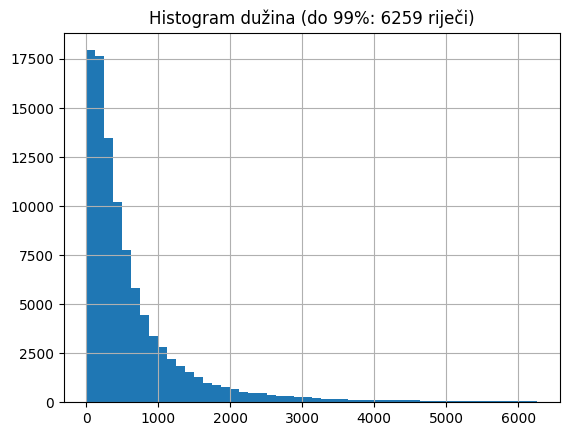

In [ ]:
max_x = df["len_words"].quantile(0.99)
ax = df.loc[df["len_words"] <= max_x, "len_words"].hist(bins=50)
ax.set_title(f"Histogram dužina (do 99%: {int(max_x)} riječi)")


**Funkcije pretprocesiranja**:
* **`normalize_text_word_only(text)` — Normalizacija teksta**
  - Pretvara u lowercase, zamijeni URL/date/year/number sa stabilnim tokenima i ukloni sve osim slova/underscore/razmaka.

* **`preprocess_tokens_word_only(text)` — Tokenizacija i čišćenje**
  - Pozove normalizaciju, razbije tekst na riječi, izbaci stopwords i prekratke tokene.

* **`word_shingles(tokens, k=2)` — Kreiranje word shinglova (n-grama)**
  - Od liste tokena napravi skup bigrama/trigrama (spojene riječi) za Jaccard/MinHash.



In [ ]:
STOP_WORDS = set(stopwords.words("english"))

URL_RE   = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)

DATE_RE  = re.compile(
    r"(\b\d{4}[-/\.]\d{1,2}[-/\.]\d{1,2}\b)|"
    r"(\b\d{1,2}[-/\.]\d{1,2}[-/\.]\d{2,4}\b)|"
    r"(\b(?:jan|feb|mar|apr|may|jun|jul|aug|sep|sept|oct|nov|dec)"
    r"[a-z]*\s+\d{1,2}(?:,\s*\d{4})?\b)",
    re.IGNORECASE
)

YEAR_RE  = re.compile(r"\b(19\d{2}|20\d{2})\b")
NUM_RE   = re.compile(r"\b\d+\b")

KEEP_RE  = re.compile(r"[^a-z_\s]+")

def normalize_text_word_only(text: str) -> str:
    text = (text or "").lower()

    text = URL_RE.sub(" url_tok ", text)
    text = DATE_RE.sub(" date_tok ", text)

    # prvo godine, pa ostali brojevi
    text = YEAR_RE.sub(" year_tok ", text)
    text = NUM_RE.sub(" num_tok ", text)

    text = KEEP_RE.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_tokens_word_only(text: str) -> List[str]:
    text = normalize_text_word_only(text)
    tokens = text.split()

    # filtriranje
    tokens = [
        t for t in tokens
        if len(t) > 1 and t not in STOP_WORDS
    ]
    return tokens

def word_shingles(tokens: List[str], k: int = 2) -> set:
    if len(tokens) < k:
        return set()
    return set(" ".join(tokens[i:i+k]) for i in range(len(tokens) - k + 1))


#Pretprocesiranje za prosli skup

In [ ]:
import pandas as pd

file_path = "/content/news-category-dataset/News_Category_Dataset_v3.json"

df = pd.read_json(file_path, lines=True)

df.head()

df.shape


(209527, 6)

Dodavanje kolone *text* koja se sadrži od *headline* i *short_description*

In [ ]:
df["text"] = df["headline"].fillna("") + " " + df["short_description"].fillna("")
df = df.dropna(subset=["text"]).reset_index(drop=True)

df[["category", "text"]].head()


,category,text
0,U.S. NEWS,Over 4 Million Americans Roll Up Sleeves For O...
1,U.S. NEWS,"American Airlines Flyer Charged, Banned For Li..."
2,COMEDY,23 Of The Funniest Tweets About Cats And Dogs ...
3,PARENTING,The Funniest Tweets From Parents This Week (Se...
4,U.S. NEWS,Woman Who Called Cops On Black Bird-Watcher Lo...


Uzorak

In [ ]:
df = df.sample(10000, random_state=42).reset_index(drop=True)
print("Broj dokumenata:", len(df))


Broj dokumenata: 10000


**Funkcije pretprocesiranja**:
* **`normalize_text_word_only(text)` — Normalizacija teksta**
  - Pretvara u lowercase, zamijeni URL/date/year/number sa stabilnim tokenima i ukloni sve osim slova/underscore/razmaka.

* **`preprocess_tokens_word_only(text)` — Tokenizacija i čišćenje**
  - Pozove normalizaciju, razbije tekst na riječi, izbaci stopwords i prekratke tokene.

* **`word_shingles(tokens, k=2)` — Kreiranje word shinglova (n-grama)**
  - Od liste tokena napravi skup bigrama/trigrama (spojene riječi) za Jaccard/MinHash.



In [ ]:
STOP_WORDS = set(stopwords.words("english"))

URL_RE   = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)

DATE_RE  = re.compile(
    r"(\b\d{4}[-/\.]\d{1,2}[-/\.]\d{1,2}\b)|"
    r"(\b\d{1,2}[-/\.]\d{1,2}[-/\.]\d{2,4}\b)|"
    r"(\b(?:jan|feb|mar|apr|may|jun|jul|aug|sep|sept|oct|nov|dec)"
    r"[a-z]*\s+\d{1,2}(?:,\s*\d{4})?\b)",
    re.IGNORECASE
)

YEAR_RE  = re.compile(r"\b(19\d{2}|20\d{2})\b")
NUM_RE   = re.compile(r"\b\d+\b")

KEEP_RE  = re.compile(r"[^a-z_\s]+")

def normalize_text_word_only(text: str) -> str:
    text = (text or "").lower()

    text = URL_RE.sub(" url_tok ", text)
    text = DATE_RE.sub(" date_tok ", text)

    text = YEAR_RE.sub(" year_tok ", text)
    text = NUM_RE.sub(" num_tok ", text)

    text = KEEP_RE.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_tokens_word_only(text: str) -> List[str]:
    text = normalize_text_word_only(text)
    tokens = text.split()

    # filtriranje
    tokens = [
        t for t in tokens
        if len(t) > 1 and t not in STOP_WORDS
    ]
    return tokens

def word_shingles(tokens: List[str], k: int = 2) -> set:
    if len(tokens) < k:
        return set()
    return set(" ".join(tokens[i:i+k]) for i in range(len(tokens) - k + 1))


#Implementirane funkcije

Hash funkcija

In [ ]:
P = (1 << 61) - 1  # veliki prost broj (Mersenne prime) za modulo

def base_hash64(s: str) -> np.uint64:
      # brzi 64-bit hash stringa (1x po shinglu)
    d = hashlib.blake2b(s.encode("utf8"), digest_size=8).digest()
    return np.uint64(int.from_bytes(d, "big"))

def make_ab(num_perm: int, seed: int = 42):
    rnd = random.Random(seed)
    a = np.array([rnd.randrange(1, P) for _ in range(num_perm)], dtype=np.uint64)
    b = np.array([rnd.randrange(0, P) for _ in range(num_perm)], dtype=np.uint64)
    return a, b

class ShingleHasher:
    """
    Generator hash-funkcija za MinHash:
    - num_perm: broj "permutacija" (dužina potpisa)
    - seed: random seed za a,b koeficijente (deterministički)
    """
    def __init__(self, num_perm: int, seed: int = 42):
        self.num_perm = int(num_perm)
        self.a, self.b = make_ab(self.num_perm, seed=seed)

    def hash_shingle(self, shingle: str, i: int) -> int:
        """
        i = index hash-funkcije (0..num_perm-1)
        vraća hash vrijednost za taj shingle i taj i
        """
        x = base_hash64(shingle)
        j = int(i) % self.num_perm
        return int((self.a[j] * x + self.b[j]) % np.uint64(P))


    def hash_all(self, x: np.uint64) -> np.ndarray:
        return (self.a * x + self.b) % np.uint64(P)


Računanje MinHash potpisa

In [ ]:
def compute_minhash_optimized(shingles, hasher):
    """
    Ručni MinHash potpis (signature) dužine hasher.num_perm.
    - shingles: iterable/set stringova
    - hasher: ShingleHasher (ima a, b, num_perm + koristi base_hash64)
    Vraća: np.ndarray dtype=uint64, shape=(num_perm,)
    """
    num_perm = hasher.num_perm

    # "inf" inicijalizacija (maksimalno veliko) – uzimamo minimume
    sig = np.full(num_perm, np.uint64(P), dtype=np.uint64)

    # edge case: prazan skup shinglova
    if not shingles:
        return sig

    for sh in shingles:
        x = base_hash64(sh)  # 1× po shinglu
        hv = hasher.hash_all(base_hash64(sh))
        sig = np.minimum(sig, hv)

    return sig


In [ ]:
def minhash_jaccard_fast(mh1, mh2) -> float:
    a = np.asarray(mh1)
    b = np.asarray(mh2)
    if a.shape != b.shape:
        raise ValueError("Potpisi moraju imati istu dužinu")
    # udio jednakih komponenti potpisa
    return float(np.mean(a == b))


In [ ]:
def band_hash_fn_bytes(band_arr: np.ndarray, band_id: int = 0) -> int:
    """
    band_arr: np.ndarray dtype=uint64 (npr. slice potpisa)
    band_id: da se isti bytes u različitim bandovima ne mapiraju identično
    vraća 64-bit int hash (determinističan)
    """
    band_arr = np.asarray(band_arr, dtype=np.uint64)
    h = hashlib.blake2b(digest_size=8)  # 64-bit output
    h.update(band_id.to_bytes(2, "little", signed=False))
    h.update(band_arr.tobytes(order="C"))
    return int.from_bytes(h.digest(), "big", signed=False)


In [ ]:
def lsh_buckets_fast(minhash_vectors, bands: int, rows: int):
    assert bands * rows == len(minhash_vectors[0])
    buckets = defaultdict(list)

    for doc_id, sig in enumerate(minhash_vectors):
        sig = np.asarray(sig, dtype=np.uint64)
        for b in range(bands):
            start, end = b * rows, (b + 1) * rows
            bh = band_hash_fn_bytes(sig[start:end], band_id=b)
            buckets[(b, bh)].append(doc_id)
    return buckets


In [ ]:
def lsh_query_fast(query_sig, buckets, bands: int, rows: int):
    """
    Vraća set kandidata koji dijele barem jedan band s query potpisom.
    - query_sig: MinHash potpis (list ili np.array uint64), dužine bands*rows
    - buckets: dict {(band_id, band_hash)-> [doc_id,...]}
    """
    query_sig = np.asarray(query_sig, dtype=np.uint64)
    assert bands * rows == len(query_sig), "bands*rows mora biti = dužina potpisa"

    candidates = set()
    for b in range(bands):
        start, end = b * rows, (b + 1) * rows
        bh = band_hash_fn_bytes(query_sig[start:end], band_id=b)  # ista funkcija kao u build
        candidates.update(buckets.get((b, bh), []))

    return candidates


Racunat ce stvarni Jaccard nad setovima shinglova

In [ ]:
def jaccard_similarity(set1, set2):
    u = set1 | set2
    return (len(set1 & set2) / len(u)) if u else 0.0


#Testiranje

Cache za shingles

In [ ]:
@lru_cache(maxsize=50000)
def shingles_for_doc(doc_id: int, k: int):
    text = df.loc[doc_id, "text"]
    toks = preprocess_tokens_word_only(text)
    return word_shingles(toks, k=k)


Funkcija koja gradi potpise za cijeli uzorak

In [ ]:
def build_signatures(df, num_perm: int, k: int, seed: int = 42):
    hasher = ShingleHasher(num_perm=num_perm, seed=seed)
    sigs = []
    t0 = time.time()

    for i in tqdm(range(len(df)), desc=f"Signatures num_perm={num_perm}, k={k}"):
        sh = shingles_for_doc(i, k)
        sig = compute_minhash_optimized(sh, hasher)
        sigs.append(sig)

    sigs = np.asarray(sigs, dtype=np.uint64)
    return sigs, (time.time() - t0)


Funkcija koja gradi LSH buckete

In [ ]:
def build_buckets(signatures, bands: int, rows: int):
    assert bands * rows == signatures.shape[1], "bands*rows mora biti = num_perm"
    t0 = time.time()
    buckets = lsh_buckets_fast(signatures, bands=bands, rows=rows)
    return buckets, (time.time() - t0)


Evaluacija prosječnog kandidata i prosječnog true Jaccard-a

In [ ]:
def evaluate_lsh(df, signatures, buckets, bands: int, rows: int, k: int,
                 N_QUERIES: int = 500, MAX_CANDS_FOR_JACC: int = 200):
    counts = []
    avg_true = []
    avg_mh = []
    t0 = time.time()

    for qid in tqdm(range(min(N_QUERIES, len(df))), desc="Evaluating queries"):
        qsig = signatures[qid]
        cands = lsh_query_fast(qsig, buckets, bands=bands, rows=rows)
        cands.discard(qid)

        counts.append(len(cands))

        sh_q = shingles_for_doc(qid, k)

        true_sims = []
        mh_sims = []

        for cid in list(cands)[:MAX_CANDS_FOR_JACC]:
            sh_c = shingles_for_doc(cid, k)
            true_sims.append(jaccard_similarity(sh_q, sh_c))
            mh_sims.append(minhash_jaccard_fast(signatures[qid], signatures[cid]))

        avg_true.append(float(np.mean(true_sims)) if true_sims else 0.0)
        avg_mh.append(float(np.mean(mh_sims)) if mh_sims else 0.0)

    return {
        "avg_candidates": float(np.mean(counts)),
        "median_candidates": float(np.median(counts)),
        "max_candidates": int(np.max(counts)) if counts else 0,
        "avg_true_jaccard": float(np.mean(avg_true)),
        "avg_minhash_jaccard": float(np.mean(avg_mh)),
        "time_eval_sec": time.time() - t0,
        "counts": counts,
        "avg_true": avg_true,
        "avg_mh": avg_mh,
    }


U nastavku će biti urađena četiri testa na 10 000 dokumenata kako bi se pronašli najbolji parametri

#Test 1

**Sweep num_perm (64/128/256), fiksno k=2 i (bands,rows)**
- Testira: koliko num_perm stabilizira procjenu i koliko košta u vremenu/memoriji.

In [ ]:
NUM_PERM_LIST = [64, 128, 256]
K = 2
SEED = 42

BAND_ROWS = {
    64:  [(16, 4), (8, 8)],
    128: [(32, 4), (16, 8)],
    256: [(64, 4), (32, 8)]
}

results = []

for num_perm in NUM_PERM_LIST:
    sigs, t_sig = build_signatures(df, num_perm=num_perm, k=K, seed=SEED)

    for (bands, rows) in BAND_ROWS[num_perm]:
        buckets, t_b = build_buckets(sigs, bands=bands, rows=rows)
        metrics = evaluate_lsh(df, sigs, buckets, bands=bands, rows=rows, k=K, N_QUERIES=50)

        results.append({
            "test": "num_perm_sweep",
            "num_perm": num_perm,
            "k": K,
            "bands": bands,
            "rows": rows,
            "build_sig_sec": t_sig,
            "build_buckets_sec": t_b,
            **{k:v for k,v in metrics.items() if k not in ["counts", "avg_sims"]}
        })

res_df = pd.DataFrame(results).sort_values(["avg_true_jaccard", "avg_candidates"], ascending=[False, True])
res_df


Evaluating queries: 100%|██████████| 50/50 [00:00<00:00, 7554.31it/s]


,test,num_perm,k,bands,rows,build_sig_sec,build_buckets_sec,avg_candidates,median_candidates,max_candidates,avg_true_jaccard,avg_minhash_jaccard,time_eval_sec,avg_true,avg_mh
0,num_perm_sweep,64,2,16,4,136.987117,1.996333,0.0,0.0,0,0.0,0.0,0.008088,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,num_perm_sweep,64,2,8,8,136.987117,3.617617,0.0,0.0,0,0.0,0.0,0.008761,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,num_perm_sweep,128,2,32,4,100.587649,6.942190,0.0,0.0,0,0.0,0.0,0.010113,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,num_perm_sweep,128,2,16,8,100.587649,0.485960,0.0,0.0,0,0.0,0.0,0.008926,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,num_perm_sweep,256,2,64,4,120.433225,10.626964,0.0,0.0,0,0.0,0.0,0.016952,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
5,num_perm_sweep,256,2,32,8,120.433225,3.553176,0.0,0.0,0,0.0,0.0,0.010555,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


#Test 2

Testira: koliko “kontekst” shinglova (unigram/bigram/trigram) popravlja kvalitetu kandidata.

In [ ]:
K_LIST = [1, 2, 3]
NUM_PERM = 128
SEED = 42
BANDS, ROWS = 16, 8

results_k = []

for K in K_LIST:
    shingles_for_doc.cache_clear()

    sigs, t_sig = build_signatures(df, num_perm=NUM_PERM, k=K, seed=SEED)
    buckets, t_b = build_buckets(sigs, bands=BANDS, rows=ROWS)
    metrics = evaluate_lsh(df, sigs, buckets, bands=BANDS, rows=ROWS, k=K, N_QUERIES=50)

    results_k.append({
        "test": "k_sweep",
        "num_perm": NUM_PERM,
        "k": K,
        "bands": BANDS,
        "rows": ROWS,
        "build_sig_sec": t_sig,
        "build_buckets_sec": t_b,
        **{k:v for k,v in metrics.items() if k not in ["counts", "avg_sims"]}
    })

pd.DataFrame(results_k).sort_values("avg_true_jaccard", ascending=False)


Evaluating queries: 100%|██████████| 50/50 [00:00<00:00, 10453.88it/s]


,test,num_perm,k,bands,rows,build_sig_sec,build_buckets_sec,avg_candidates,median_candidates,max_candidates,avg_true_jaccard,avg_minhash_jaccard,time_eval_sec,avg_true,avg_mh
0,k_sweep,128,1,16,8,109.405696,1.426339,0.0,0.0,0,0.0,0.0,0.007997,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,k_sweep,128,2,16,8,157.808657,1.798446,0.0,0.0,0,0.0,0.0,0.008053,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,k_sweep,128,3,16,8,171.992192,2.632547,0.0,0.0,0,0.0,0.0,0.008463,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


#Test 3

Tradeoff bands/rows (preciznost vs broj kandidata) uz fiksni num_perm=128, k=2

Što testira:

- više bandova / manje rowova → više kandidata (veći recall, manja preciznost)

- manje bandova / više rowova → manje kandidata (manji recall, veća preciznost)

In [ ]:
NUM_PERM = 128
K = 2
SEED = 42

BR_GRID = [(64,2), (32,4), (16,8), (8,16), (4,32)]

shingles_for_doc.cache_clear()
sigs, t_sig = build_signatures(df, num_perm=NUM_PERM, k=K, seed=SEED)

results_br = []
for (bands, rows) in BR_GRID:
    buckets, t_b = build_buckets(sigs, bands=bands, rows=rows)
    metrics = evaluate_lsh(df, sigs, buckets, bands=bands, rows=rows, k=K, N_QUERIES=50)

    results_br.append({
        "test": "bands_rows_tradeoff",
        "num_perm": NUM_PERM,
        "k": K,
        "bands": bands,
        "rows": rows,
        "build_sig_sec": t_sig,
        "build_buckets_sec": t_b,
        **{k:v for k,v in metrics.items() if k not in ["counts", "avg_sims"]}
    })

pd.DataFrame(results_br).sort_values(["avg_true_jaccard", "avg_candidates"], ascending=[False, True])


Evaluating queries: 100%|██████████| 50/50 [00:00<00:00, 21211.21it/s]


,test,num_perm,k,bands,rows,build_sig_sec,build_buckets_sec,avg_candidates,median_candidates,max_candidates,avg_true_jaccard,avg_minhash_jaccard,time_eval_sec,avg_true,avg_mh
0,bands_rows_tradeoff,128,2,64,2,161.218122,5.879375,5.32,1.0,76,0.002784,0.011649,0.136975,"[0.0039695666556400925, 0.0, 0.0, 0.0067111864...","[0.015625, 0.0, 0.0, 0.023003472222222224, 0.0..."
1,bands_rows_tradeoff,128,2,32,4,161.218122,4.818776,0.00,0.0,0,0.000000,0.000000,0.015859,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,bands_rows_tradeoff,128,2,16,8,161.218122,1.019364,0.00,0.0,0,0.000000,0.000000,0.012190,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,bands_rows_tradeoff,128,2,8,16,161.218122,0.545492,0.00,0.0,0,0.000000,0.000000,0.013313,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,bands_rows_tradeoff,128,2,4,32,161.218122,2.845262,0.00,0.0,0,0.000000,0.000000,0.006330,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


#Test 4

Stabilnost na seed da se pokaže varijacija

Što testira: koliko rezultati osciliraju kad promijeniš random parametre hash-funkcija.

In [ ]:
NUM_PERM = 128
K = 2
BANDS, ROWS = 16, 8
SEEDS = [1, 7, 42, 99]

results_seed = []

for SEED in SEEDS:
    shingles_for_doc.cache_clear()
    sigs, t_sig = build_signatures(df, num_perm=NUM_PERM, k=K, seed=SEED)
    buckets, t_b = build_buckets(sigs, bands=BANDS, rows=ROWS)
    metrics = evaluate_lsh(df, sigs, buckets, bands=BANDS, rows=ROWS, k=K, N_QUERIES=50)

    results_seed.append({
        "test": "seed_stability",
        "seed": SEED,
        "num_perm": NUM_PERM,
        "k": K,
        "bands": BANDS,
        "rows": ROWS,
        "build_sig_sec": t_sig,
        "build_buckets_sec": t_b,
        **{k:v for k,v in metrics.items() if k not in ["counts", "avg_sims"]}
    })

pd.DataFrame(results_seed).sort_values("avg_true_jaccard", ascending=False)


Evaluating queries: 100%|██████████| 50/50 [00:00<00:00, 17191.18it/s]


,test,seed,num_perm,k,bands,rows,build_sig_sec,build_buckets_sec,avg_candidates,median_candidates,max_candidates,avg_true_jaccard,avg_minhash_jaccard,time_eval_sec,avg_true,avg_mh
0,seed_stability,1,128,2,16,8,153.902940,1.260999,0.0,0.0,0,0.0,0.0,0.009233,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,seed_stability,7,128,2,16,8,151.729658,1.682934,0.0,0.0,0,0.0,0.0,0.005463,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,seed_stability,42,128,2,16,8,150.309519,1.744243,0.0,0.0,0,0.0,0.0,0.010386,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,seed_stability,99,128,2,16,8,151.698419,1.283293,0.0,0.0,0,0.0,0.0,0.006958,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


#Brute force vs LSH

In [ ]:
def brute_force_topk(qid: int, k_shingle: int, topk: int = 10):
    sh_q = shingles_for_doc(qid, k_shingle)
    scores = []
    for cid in range(len(df)):
        if cid == qid:
            continue
        sh_c = shingles_for_doc(cid, k_shingle)
        sim = jaccard_similarity(sh_q, sh_c)
        scores.append((cid, sim))
    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:topk]

def lsh_topk(qid: int, signatures, buckets, bands: int, rows: int, k_shingle: int, topk: int = 10):
    qsig = signatures[qid]
    cands = lsh_query_fast(qsig, buckets, bands=bands, rows=rows)
    cands.discard(qid)

    sh_q = shingles_for_doc(qid, k_shingle)
    scores = []
    for cid in cands:
        sh_c = shingles_for_doc(cid, k_shingle)
        sim = jaccard_similarity(sh_q, sh_c)
        scores.append((cid, sim))

    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:topk], len(cands)


def compare_lsh_vs_bruteforce(signatures, buckets, bands: int, rows: int, k_shingle: int,
                             N_QUERIES: int = 50, TOPK: int = 10, seed: int = 42):
    rnd = random.Random(seed)
    qids = rnd.sample(range(len(df)), N_QUERIES)

    t_lsh_total = 0.0
    t_br_total = 0.0
    hits = []
    cand_counts = []

    for qid in qids:
        # LSH
        t0 = time.time()
        lsh_res, n_cands = lsh_topk(qid, signatures, buckets, bands, rows, k_shingle, topk=TOPK)
        t_lsh_total += (time.time() - t0)
        cand_counts.append(n_cands)

        # Brute-force
        t0 = time.time()
        br_res = brute_force_topk(qid, k_shingle, topk=TOPK)
        t_br_total += (time.time() - t0)

        # hit@TOPK (preklop ID-eva)
        lsh_ids = {cid for cid, _ in lsh_res}
        br_ids  = {cid for cid, _ in br_res}
        hits.append(len(lsh_ids & br_ids) / TOPK)

    return {
        "N_queries": N_QUERIES,
        "topk": TOPK,
        "bands": bands,
        "rows": rows,
        "k_shingle": k_shingle,
        "time_lsh_sec": t_lsh_total,
        "time_bruteforce_sec": t_br_total,
        "speedup_x": (t_br_total / t_lsh_total) if t_lsh_total > 0 else np.inf,
        "avg_candidates": float(np.mean(cand_counts)),
        "median_candidates": float(np.median(cand_counts)),
        "hit_at_topk": float(np.mean(hits)),
    }


In [ ]:
BEST_NUM_PERM = 128
BEST_K = 2
BEST_SEED = 42
BEST_BANDS = 64
BEST_ROWS = 2

NUM_PERM = BEST_NUM_PERM
K = BEST_K
SEED = BEST_SEED
BANDS = BEST_BANDS
ROWS = BEST_ROWS

shingles_for_doc.cache_clear()
sigs, _ = build_signatures(df, num_perm=NUM_PERM, k=K, seed=SEED)
buckets, _ = build_buckets(sigs, bands=BANDS, rows=ROWS)

report = compare_lsh_vs_bruteforce(
    signatures=sigs,        # potpisi izgrađeni za taj num_perm i k
    buckets=buckets,        # bucketi za taj bands/rows
    bands=BEST_BANDS,
    rows=BEST_ROWS,
    k_shingle=BEST_K,
    N_QUERIES=50,
    TOPK=10,
    seed=42
)

report


Signatures num_perm=128, k=2: 100%|██████████| 20000/20000 [03:42<00:00, 89.88it/s] 


{'N_queries': 50,
 'topk': 10,
 'bands': 64,
 'rows': 2,
 'k_shingle': 2,
 'time_lsh_sec': 0.04603219032287598,
 'time_bruteforce_sec': 78.64376974105835,
 'speedup_x': 1708.4516115666095,
 'avg_candidates': 15.68,
 'median_candidates': 2.0,
 'hit_at_topk': 0.132}

Funkcija za pravljenje uzorka

In [ ]:
def make_subset_df(df, N, seed=42, mode="first"):
    if mode == "first":
        return df.iloc[:N].copy().reset_index(drop=True)
    elif mode == "random":
        return df.sample(N, random_state=seed).copy().reset_index(drop=True)
    else:
        raise ValueError("mode must be 'first' or 'random'")


Testiranje više različitih uzoraka

In [ ]:
results = []

df_full = df.copy()

for N in [1000, 4000, 10000, 15000, 20000]:
    dfN = make_subset_df(df_full, N, seed=42, mode="random")
    df = dfN
    shingles_for_doc.cache_clear()

    sigs, _ = build_signatures(df, num_perm=BEST_NUM_PERM, k=BEST_K, seed=BEST_SEED)
    buckets, _ = build_buckets(sigs, bands=BEST_BANDS, rows=BEST_ROWS)

    report = compare_lsh_vs_bruteforce(
        signatures=sigs, buckets=buckets,
        bands=BEST_BANDS, rows=BEST_ROWS,
        k_shingle=BEST_K,
        N_QUERIES=50, TOPK=10, seed=42
    )

    report["N_docs"] = N
    results.append(report)

res_df = pd.DataFrame(results).sort_values("N_docs")
display(res_df[["N_docs","time_lsh_sec","time_bruteforce_sec","speedup_x","avg_candidates","hit_at_topk"]])


Signatures num_perm=128, k=2: 100%|██████████| 20000/20000 [02:39<00:00, 125.55it/s]


,N_docs,time_lsh_sec,time_bruteforce_sec,speedup_x,avg_candidates,hit_at_topk
0,1000,0.014643,2.247047,153.450870,0.96,0.032
1,4000,0.020727,10.999752,530.686647,3.04,0.092
2,10000,0.028740,34.231147,1191.046032,4.86,0.058
3,15000,0.037527,45.701160,1217.818037,14.88,0.068
4,20000,0.051169,57.091223,1115.745472,29.68,0.204


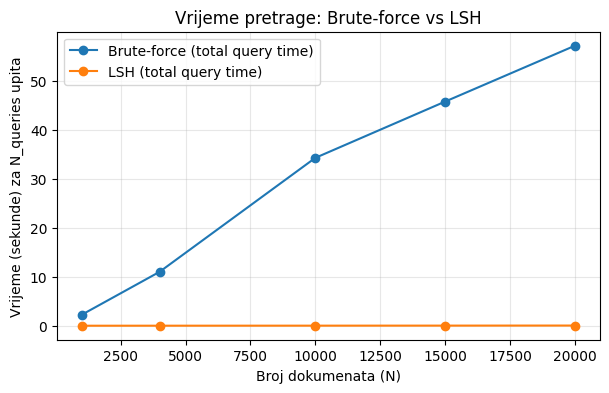

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(res_df["N_docs"], res_df["time_bruteforce_sec"], marker="o", label="Brute-force (total query time)")
plt.plot(res_df["N_docs"], res_df["time_lsh_sec"], marker="o", label="LSH (total query time)")
plt.xlabel("Broj dokumenata (N)")
plt.ylabel("Vrijeme (sekunde) za N_queries upita")
plt.title("Vrijeme pretrage: Brute-force vs LSH")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


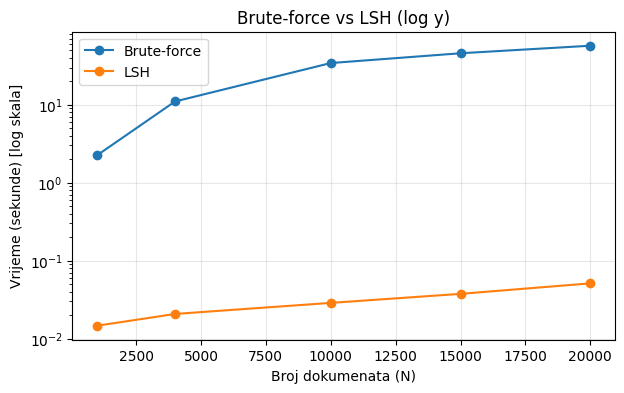

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(res_df["N_docs"], res_df["time_bruteforce_sec"], marker="o", label="Brute-force")
plt.plot(res_df["N_docs"], res_df["time_lsh_sec"], marker="o", label="LSH")
plt.yscale("log")
plt.xlabel("Broj dokumenata (N)")
plt.ylabel("Vrijeme (sekunde) [log skala]")
plt.title("Brute-force vs LSH (log y)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Speedup vs N

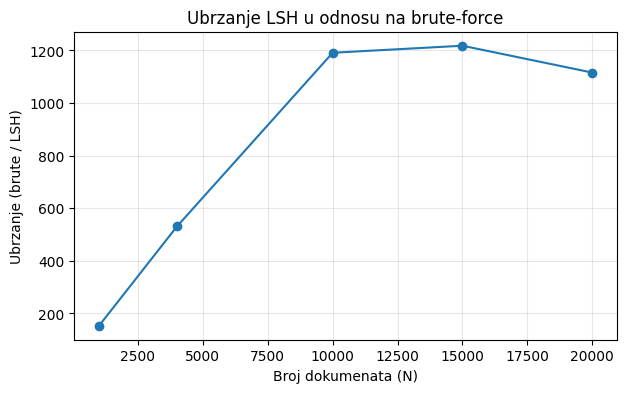

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(res_df["N_docs"], res_df["speedup_x"], marker="o")
plt.xlabel("Broj dokumenata (N)")
plt.ylabel("Ubrzanje (brute / LSH)")
plt.title("Ubrzanje LSH u odnosu na brute-force")
plt.grid(True, alpha=0.3)
plt.show()


#Evaluacija LSH

In [ ]:
BEST_NUM_PERM = 128
BEST_K = 2
BEST_SEED = 42
BEST_BANDS = 64
BEST_ROWS = 2

In [ ]:
def evaluate_lsh_only(
    df,
    signatures,
    buckets,
    bands: int,
    rows: int,
    k_shingle: int,
    N_QUERIES: int = 50,
    MAX_CANDS_FOR_JACC: int = 200,
    seed: int = 42,
    compute_quality: bool = True,
):
    """
    Vraća statistike: vrijeme, kandidati, nonempty rate,
    + opcionalno avg_true_jaccard i avg_minhash_jaccard.
    """
    rng = np.random.default_rng(seed)
    n_docs = len(df)
    qids = rng.choice(n_docs, size=min(N_QUERIES, n_docs), replace=False)

    counts = []
    avg_true = []
    avg_mh = []

    t0 = time.time()
    for qid in tqdm(qids, desc=f"LSH eval (Nq={len(qids)})"):
        qsig = signatures[qid]
        cands = lsh_query_fast(qsig, buckets, bands=bands, rows=rows)
        cands.discard(qid)

        counts.append(len(cands))

        if compute_quality:
            sh_q = shingles_for_doc(qid, k_shingle)

            true_sims = []
            mh_sims = []

            for cid in list(cands)[:MAX_CANDS_FOR_JACC]:
                sh_c = shingles_for_doc(cid, k_shingle)
                true_sims.append(jaccard_similarity(sh_q, sh_c))
                mh_sims.append(minhash_jaccard_fast(signatures[qid], signatures[cid]))

            avg_true.append(float(np.mean(true_sims)) if true_sims else 0.0)
            avg_mh.append(float(np.mean(mh_sims)) if mh_sims else 0.0)

    t_eval = time.time() - t0

    counts_arr = np.array(counts, dtype=np.int32)
    nonempty = counts_arr > 0

    report = {
        "N_queries": int(len(qids)),
        "time_lsh_eval_sec": float(t_eval),
        "time_per_query_ms": float((t_eval / max(1, len(qids))) * 1000.0),

        "avg_candidates": float(counts_arr.mean()) if len(counts_arr) else 0.0,
        "median_candidates": float(np.median(counts_arr)) if len(counts_arr) else 0.0,
        "p95_candidates": float(np.percentile(counts_arr, 95)) if len(counts_arr) else 0.0,
        "max_candidates": int(counts_arr.max()) if len(counts_arr) else 0,

        "nonempty_rate": float(nonempty.mean()) if len(counts_arr) else 0.0,
        "avg_candidates_nonempty": float(counts_arr[nonempty].mean()) if nonempty.any() else 0.0,
    }

    if compute_quality:
        report["avg_true_jaccard"] = float(np.mean(avg_true)) if avg_true else 0.0
        report["avg_minhash_jaccard"] = float(np.mean(avg_mh)) if avg_mh else 0.0

    return report


results = []

df_full = df.copy()

for N in [1000, 4000, 10000, 15000, 20000]:
    dfN = make_subset_df(df_full, N, seed=42, mode="random")

    df = dfN
    shingles_for_doc.cache_clear()

    t0 = time.time()
    sigs, t_sig = build_signatures(df, num_perm=BEST_NUM_PERM, k=BEST_K, seed=BEST_SEED)
    t_sig = float(t_sig) if t_sig is not None else float(time.time() - t0)

    t1 = time.time()
    buckets, t_b = build_buckets(sigs, bands=BEST_BANDS, rows=BEST_ROWS)
    t_b = float(t_b) if t_b is not None else float(time.time() - t1)

    rep50 = evaluate_lsh_only(
        df=df, signatures=sigs, buckets=buckets,
        bands=BEST_BANDS, rows=BEST_ROWS,
        k_shingle=BEST_K,
        N_QUERIES=50,
        MAX_CANDS_FOR_JACC=200,
        seed=42,
        compute_quality=True,
    )

    rep500 = evaluate_lsh_only(
        df=df, signatures=sigs, buckets=buckets,
        bands=BEST_BANDS, rows=BEST_ROWS,
        k_shingle=BEST_K,
        N_QUERIES=500,
        MAX_CANDS_FOR_JACC=200,
        seed=42,
        compute_quality=True,
    )

    report = {
        "N_docs": N,
        "build_sig_sec": t_sig,
        "build_buckets_sec": t_b,

        # NQ=50
        "time_eval_50_sec": rep50["time_lsh_eval_sec"],
        "avg_cands_50": rep50["avg_candidates"],
        "med_cands_50": rep50["median_candidates"],
        "p95_cands_50": rep50["p95_candidates"],
        "nonempty_50": rep50["nonempty_rate"],
        "avg_true_50": rep50.get("avg_true_jaccard", np.nan),
        "avg_mh_50": rep50.get("avg_minhash_jaccard", np.nan),

        # NQ=500
        "time_eval_500_sec": rep500["time_lsh_eval_sec"],
        "avg_cands_500": rep500["avg_candidates"],
        "med_cands_500": rep500["median_candidates"],
        "p95_cands_500": rep500["p95_candidates"],
        "nonempty_500": rep500["nonempty_rate"],
        "avg_true_500": rep500.get("avg_true_jaccard", np.nan),
        "avg_mh_500": rep500.get("avg_minhash_jaccard", np.nan),
    }

    report["eval_slowdown_500_vs_50_x"] = (
        report["time_eval_500_sec"] / report["time_eval_50_sec"]
        if report["time_eval_50_sec"] > 0 else np.nan
    )

    results.append(report)

res_df = pd.DataFrame(results).sort_values("N_docs")

display_cols = [
    "N_docs",
    "build_sig_sec", "build_buckets_sec",
    "time_eval_50_sec", "time_eval_500_sec", "eval_slowdown_500_vs_50_x",
    "avg_cands_50", "med_cands_50", "p95_cands_50", "nonempty_50",
    "avg_cands_500", "med_cands_500", "p95_cands_500", "nonempty_500",
    "avg_true_50", "avg_true_500",
]
display(res_df[display_cols])


LSH eval (Nq=500): 100%|██████████| 500/500 [00:00<00:00, 920.84it/s] 


,N_docs,build_sig_sec,build_buckets_sec,time_eval_50_sec,time_eval_500_sec,eval_slowdown_500_vs_50_x,avg_cands_50,med_cands_50,p95_cands_50,nonempty_50,avg_cands_500,med_cands_500,p95_cands_500,nonempty_500,avg_true_50,avg_true_500
0,1000,6.102427,0.201317,0.015780,0.119329,7.561809,0.80,0.0,3.55,0.36,0.956,0.0,5.00,0.286,0.013861,0.012956
1,4000,28.405621,1.922798,0.028107,0.360385,12.822043,3.08,0.0,24.00,0.42,5.764,0.0,38.05,0.490,0.019277,0.017085
2,10000,72.817776,4.134964,0.085287,0.585934,6.870122,27.82,1.0,208.75,0.58,11.814,1.0,61.05,0.614,0.012240,0.024322
3,15000,108.698866,5.448570,0.067300,0.748118,11.116238,16.88,2.0,60.35,0.58,21.444,2.0,131.05,0.656,0.013102,0.023601
4,20000,143.319883,6.458958,0.058604,0.547796,9.347420,21.46,2.0,114.10,0.60,25.458,3.0,151.95,0.678,0.022900,0.025309


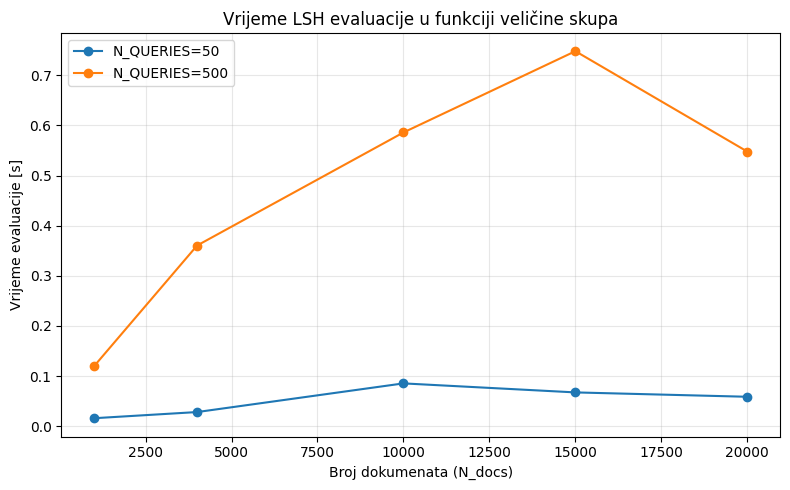

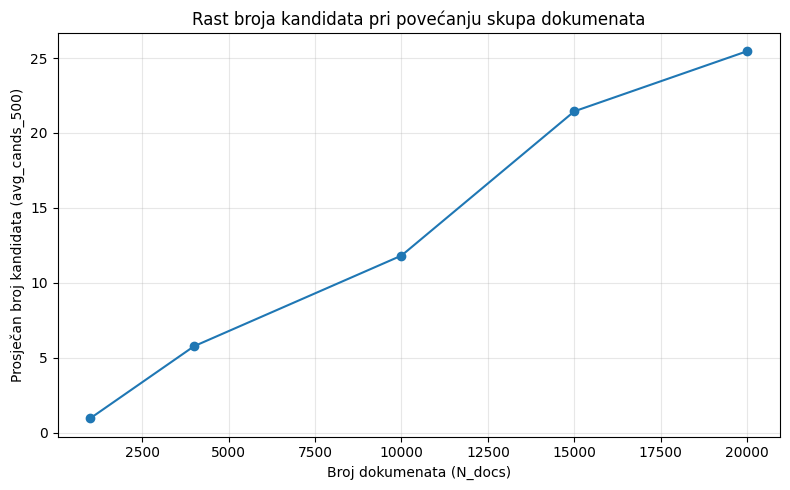

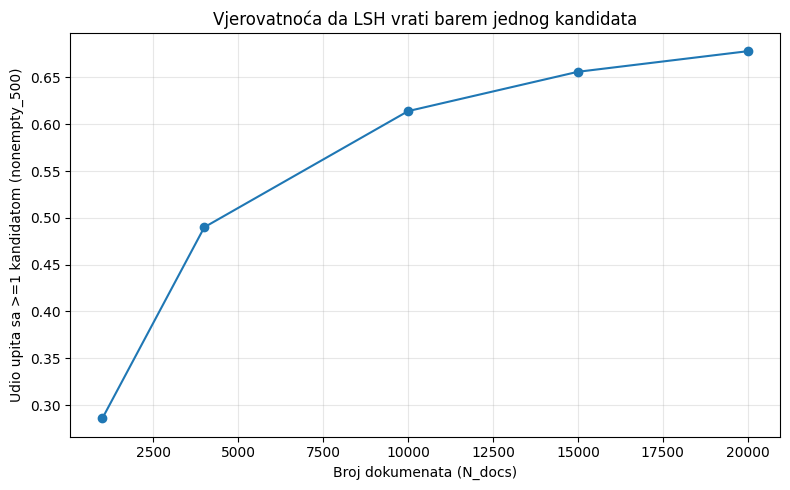

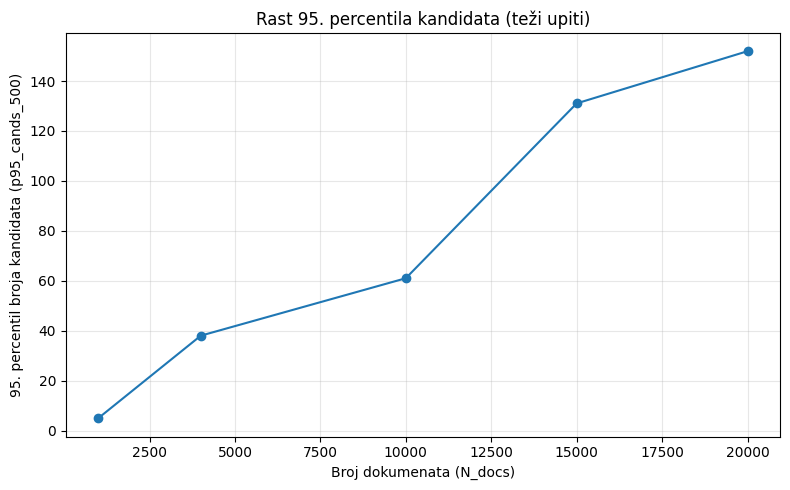

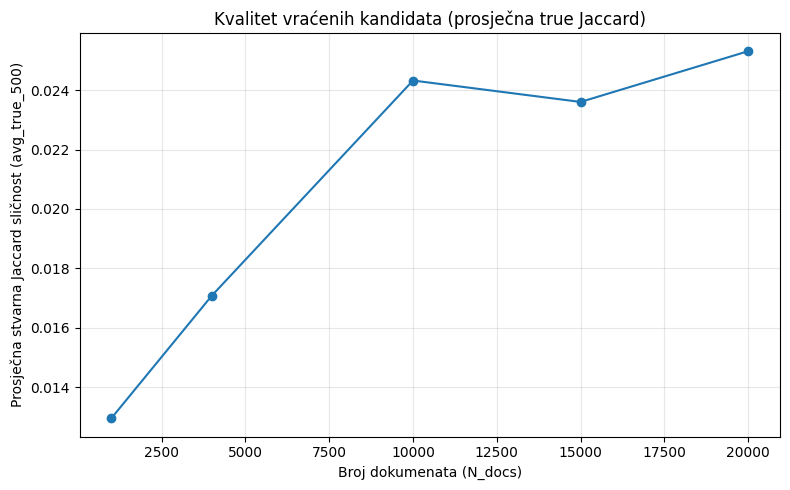

In [ ]:
plot_df = res_df.sort_values("N_docs").copy()

# 1) Vrijeme evaluacije: 50 vs 500 upita
plt.figure(figsize=(8, 5))
plt.plot(plot_df["N_docs"], plot_df["time_eval_50_sec"], marker="o", label="N_QUERIES=50")
plt.plot(plot_df["N_docs"], plot_df["time_eval_500_sec"], marker="o", label="N_QUERIES=500")
plt.xlabel("Broj dokumenata (N_docs)")
plt.ylabel("Vrijeme evaluacije [s]")
plt.title("Vrijeme LSH evaluacije u funkciji veličine skupa")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 2) Prosječan broj kandidata (za 500 upita) — pokazuje rast “posla” nakon LSH
plt.figure(figsize=(8, 5))
plt.plot(plot_df["N_docs"], plot_df["avg_cands_500"], marker="o")
plt.xlabel("Broj dokumenata (N_docs)")
plt.ylabel("Prosječan broj kandidata (avg_cands_500)")
plt.title("Rast broja kandidata pri povećanju skupa dokumenata")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3) Nonempty rate — koliko upita dobije bar jednog kandidata
plt.figure(figsize=(8, 5))
plt.plot(plot_df["N_docs"], plot_df["nonempty_500"], marker="o")
plt.xlabel("Broj dokumenata (N_docs)")
plt.ylabel("Udio upita sa >=1 kandidatom (nonempty_500)")
plt.title("Vjerovatnoća da LSH vrati barem jednog kandidata")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4) “Rep” distribucije: p95 kandidata (za 500 upita)
plt.figure(figsize=(8, 5))
plt.plot(plot_df["N_docs"], plot_df["p95_cands_500"], marker="o")
plt.xlabel("Broj dokumenata (N_docs)")
plt.ylabel("95. percentil broja kandidata (p95_cands_500)")
plt.title("Rast 95. percentila kandidata (teži upiti)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5) Kvalitet kandidata: avg_true_jaccard (za 500 upita)
plt.figure(figsize=(8, 5))
plt.plot(plot_df["N_docs"], plot_df["avg_true_500"], marker="o")
plt.xlabel("Broj dokumenata (N_docs)")
plt.ylabel("Prosječna stvarna Jaccard sličnost (avg_true_500)")
plt.title("Kvalitet vraćenih kandidata (prosječna true Jaccard)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


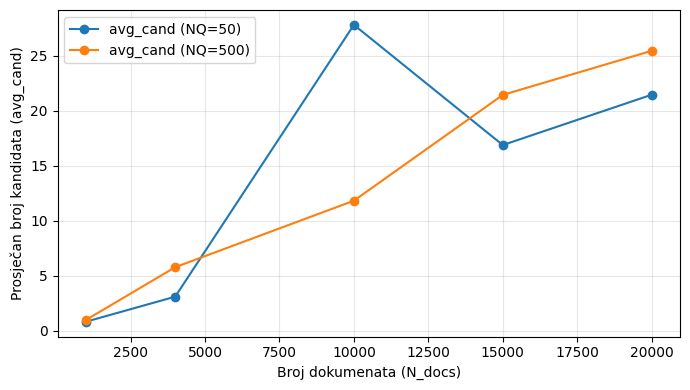

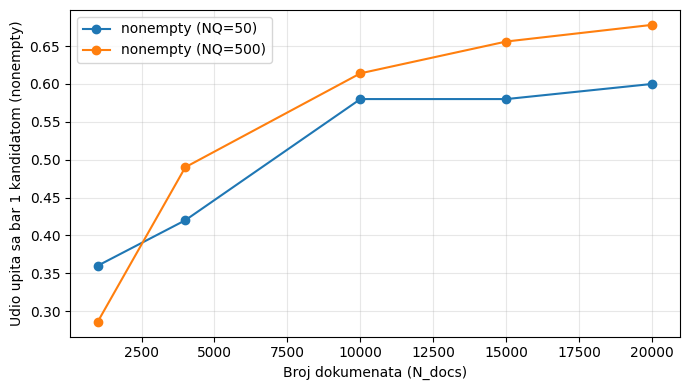

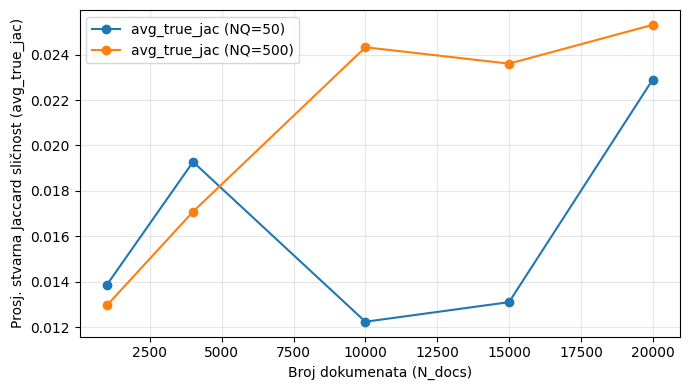

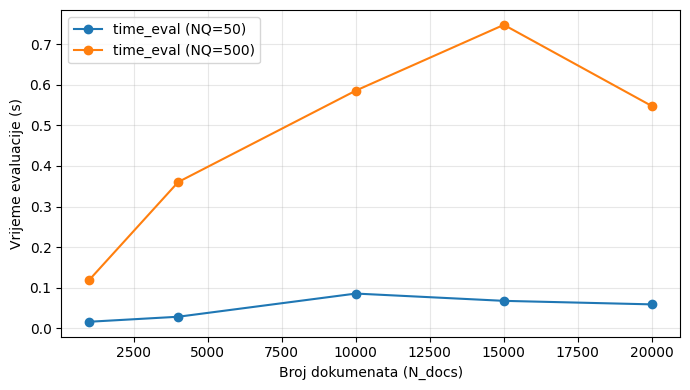

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Unesi rezultate iz tabele (ili napravi df direktno iz svog res_df)
data = [
    {"N_docs":1000,  "avg_cand_50":0.80,  "nonempty_50":0.36, "avg_true_50":0.013861,
                 "avg_cand_500":0.956, "nonempty_500":0.286,"avg_true_500":0.012956,
                 "t50":0.015780, "t500":0.119329},
    {"N_docs":4000,  "avg_cand_50":3.08,  "nonempty_50":0.42, "avg_true_50":0.019277,
                 "avg_cand_500":5.764, "nonempty_500":0.490,"avg_true_500":0.017085,
                 "t50":0.028107, "t500":0.360385},
    {"N_docs":10000, "avg_cand_50":27.82, "nonempty_50":0.58, "avg_true_50":0.012240,
                 "avg_cand_500":11.814,"nonempty_500":0.614,"avg_true_500":0.024322,
                 "t50":0.085287, "t500":0.585934},
    {"N_docs":15000, "avg_cand_50":16.88, "nonempty_50":0.58, "avg_true_50":0.013102,
                 "avg_cand_500":21.444,"nonempty_500":0.656,"avg_true_500":0.023601,
                 "t50":0.067300, "t500":0.748118},
    {"N_docs":20000, "avg_cand_50":21.46, "nonempty_50":0.60, "avg_true_50":0.022900,
                 "avg_cand_500":25.458,"nonempty_500":0.678,"avg_true_500":0.025309,
                 "t50":0.058604, "t500":0.547796},
]
dfv = pd.DataFrame(data).sort_values("N_docs")

# 1) avg candidates: 50 vs 500
plt.figure(figsize=(7,4))
plt.plot(dfv["N_docs"], dfv["avg_cand_50"], marker="o", label="avg_cand (NQ=50)")
plt.plot(dfv["N_docs"], dfv["avg_cand_500"], marker="o", label="avg_cand (NQ=500)")
plt.xlabel("Broj dokumenata (N_docs)")
plt.ylabel("Prosječan broj kandidata (avg_cand)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 2) nonempty rate: 50 vs 500
plt.figure(figsize=(7,4))
plt.plot(dfv["N_docs"], dfv["nonempty_50"], marker="o", label="nonempty (NQ=50)")
plt.plot(dfv["N_docs"], dfv["nonempty_500"], marker="o", label="nonempty (NQ=500)")
plt.xlabel("Broj dokumenata (N_docs)")
plt.ylabel("Udio upita sa bar 1 kandidatom (nonempty)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 3) avg true jaccard: 50 vs 500
plt.figure(figsize=(7,4))
plt.plot(dfv["N_docs"], dfv["avg_true_50"], marker="o", label="avg_true_jac (NQ=50)")
plt.plot(dfv["N_docs"], dfv["avg_true_500"], marker="o", label="avg_true_jac (NQ=500)")
plt.xlabel("Broj dokumenata (N_docs)")
plt.ylabel("Prosj. stvarna Jaccard sličnost (avg_true_jac)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 4) vrijeme evaluacije: 50 vs 500 (opciono, ali super da se vidi poenta)
plt.figure(figsize=(7,4))
plt.plot(dfv["N_docs"], dfv["t50"], marker="o", label="time_eval (NQ=50)")
plt.plot(dfv["N_docs"], dfv["t500"], marker="o", label="time_eval (NQ=500)")
plt.xlabel("Broj dokumenata (N_docs)")
plt.ylabel("Vrijeme evaluacije (s)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


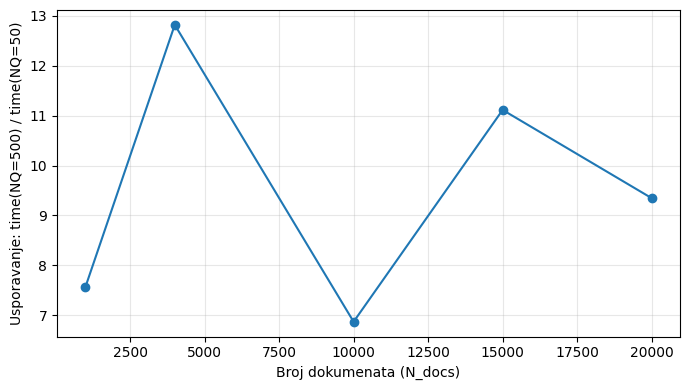

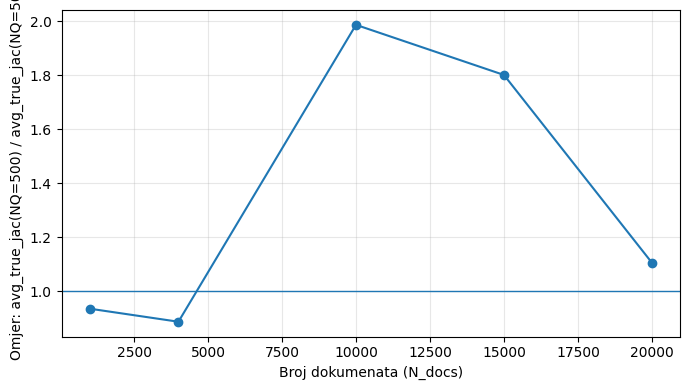

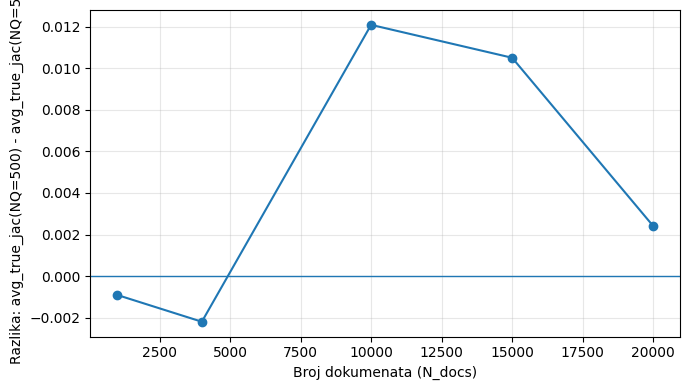

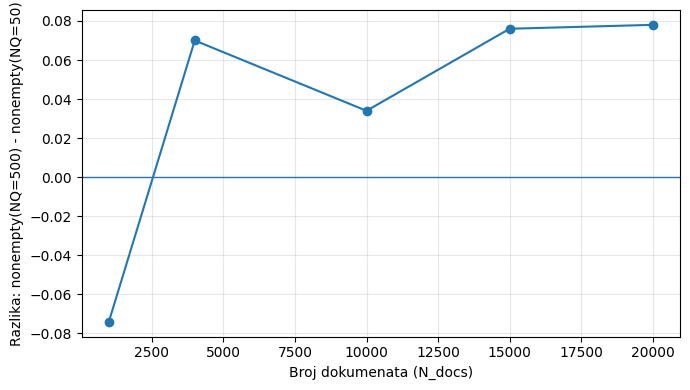

,N_docs,t50,t500,ratio_time_500_50,avg_true_50,avg_true_500,ratio_true_500_50,diff_true_500_50,nonempty_50,nonempty_500,ratio_nonempty_500_50,diff_nonempty_500_50
0,1000,0.015780,0.119329,7.562041,0.013861,0.012956,0.934709,-0.000905,0.36,0.286,0.794444,-0.074
1,4000,0.028107,0.360385,12.821895,0.019277,0.017085,0.886289,-0.002192,0.42,0.490,1.166667,0.070
2,10000,0.085287,0.585934,6.870144,0.012240,0.024322,1.987092,0.012082,0.58,0.614,1.058621,0.034
3,15000,0.067300,0.748118,11.116166,0.013102,0.023601,1.801328,0.010499,0.58,0.656,1.131034,0.076
4,20000,0.058604,0.547796,9.347417,0.022900,0.025309,1.105197,0.002409,0.60,0.678,1.130000,0.078


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

eps = 1e-12
dfv["ratio_time_500_50"] = dfv["t500"] / (dfv["t50"] + eps)
dfv["ratio_true_500_50"] = dfv["avg_true_500"] / (dfv["avg_true_50"] + eps)
dfv["ratio_nonempty_500_50"] = dfv["nonempty_500"] / (dfv["nonempty_50"] + eps)
dfv["diff_true_500_50"] = dfv["avg_true_500"] - dfv["avg_true_50"]
dfv["diff_nonempty_500_50"] = dfv["nonempty_500"] - dfv["nonempty_50"]

# 1) Koliko puta je sporije (t500 / t50)
plt.figure(figsize=(7,4))
plt.plot(dfv["N_docs"], dfv["ratio_time_500_50"], marker="o")
plt.xlabel("Broj dokumenata (N_docs)")
plt.ylabel("Usporavanje: time(NQ=500) / time(NQ=50)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Odnos kvaliteta: avg_true_500 / avg_true_50
plt.figure(figsize=(7,4))
plt.plot(dfv["N_docs"], dfv["ratio_true_500_50"], marker="o")
plt.axhline(1.0, linewidth=1)  # referenca: isto kao NQ=50
plt.xlabel("Broj dokumenata (N_docs)")
plt.ylabel("Omjer: avg_true_jac(NQ=500) / avg_true_jac(NQ=50)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3) Razlika kvaliteta: avg_true_500 - avg_true_50 (lakše za čitati nego ratio)
plt.figure(figsize=(7,4))
plt.plot(dfv["N_docs"], dfv["diff_true_500_50"], marker="o")
plt.axhline(0.0, linewidth=1)  # referenca: nema promjene
plt.xlabel("Broj dokumenata (N_docs)")
plt.ylabel("Razlika: avg_true_jac(NQ=500) - avg_true_jac(NQ=50)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4) Razlika nonempty: nonempty_500 - nonempty_50
plt.figure(figsize=(7,4))
plt.plot(dfv["N_docs"], dfv["diff_nonempty_500_50"], marker="o")
plt.axhline(0.0, linewidth=1)
plt.xlabel("Broj dokumenata (N_docs)")
plt.ylabel("Razlika: nonempty(NQ=500) - nonempty(NQ=50)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# (opciono) Sažetak u tabeli da vidiš brojeve odmah u notebooku
cols = ["N_docs",
        "t50","t500","ratio_time_500_50",
        "avg_true_50","avg_true_500","ratio_true_500_50","diff_true_500_50",
        "nonempty_50","nonempty_500","ratio_nonempty_500_50","diff_nonempty_500_50"]
display(dfv[cols])


#Vizualizacija

Broj kandidata i prosjecna stvarna slicnost

In [ ]:
BEST_K = 2
BEST_BANDS = 64
BEST_ROWS = 2

EVAL_Q = min(10000, len(df))
counts = []
avg_sims = []

for qid in tqdm(range(EVAL_Q), desc="Evaluating BEST LSH (manual)"):
    # kandidati iz ručnog LSH
    cands = lsh_query_fast(sigs[qid], buckets, bands=BEST_BANDS, rows=BEST_ROWS)
    cands.discard(qid)

    counts.append(len(cands))

    # prosječna stvarna Jaccard sličnost (nad shinglovima)
    sh_q = shingles_for_doc(qid, BEST_K)

    sims = []
    for cid in list(cands):
        sh_c = shingles_for_doc(cid, BEST_K)
        sims.append(jaccard_similarity(sh_q, sh_c))

    avg_sims.append(float(np.mean(sims)) if sims else 0.0)

print("Gotovo – evaluirano", EVAL_Q, "querya.")


Evaluating BEST LSH (manual): 100%|██████████| 10000/10000 [00:11<00:00, 882.12it/s]

Gotovo – evaluirano 10000 querya.


Top 5 query-ja, histogram i scatter

Top 5 query dokumenata s najviše kandidata:
1. Query ID: 6619, Broj kandidata: 662, Prosj. Jaccard: 0.031
2. Query ID: 5253, Broj kandidata: 595, Prosj. Jaccard: 0.030
3. Query ID: 2142, Broj kandidata: 568, Prosj. Jaccard: 0.024
4. Query ID: 4546, Broj kandidata: 551, Prosj. Jaccard: 0.029
5. Query ID: 9598, Broj kandidata: 541, Prosj. Jaccard: 0.029


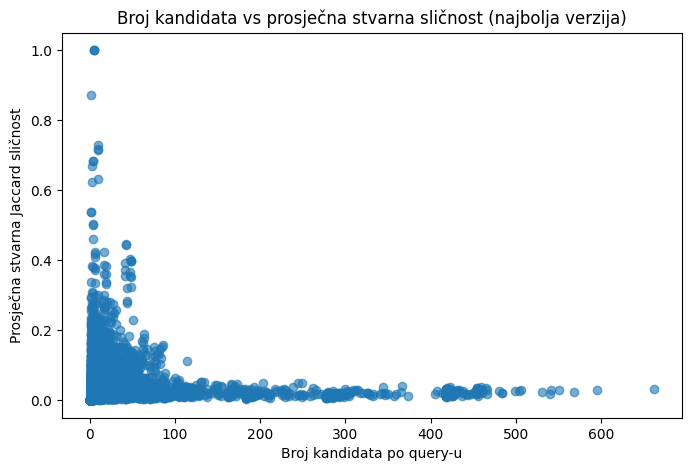

In [ ]:
top5_indices = np.argsort(counts)[-5:][::-1]
print("Top 5 query dokumenata s najviše kandidata:")
for rank, qid in enumerate(top5_indices, 1):
    print(f"{rank}. Query ID: {qid}, Broj kandidata: {counts[qid]}, Prosj. Jaccard: {avg_sims[qid]:.3f}")



# Scatter: broj kandidata vs prosječna sličnost
plt.figure(figsize=(8,5))
plt.scatter(counts, avg_sims, alpha=0.6)
plt.xlabel("Broj kandidata po query-u")
plt.ylabel("Prosječna stvarna Jaccard sličnost")
plt.title("Broj kandidata vs prosječna stvarna sličnost (najbolja verzija)")
plt.show()


Detaljna analiza top 5 query-ja

In [ ]:
for rank, qid in enumerate(top5_indices, 1):
    print(f"\n=== Query {rank}: ID {qid} ===")
    print("Title:", df.loc[qid, "title"])

    cands = lsh_query_fast(sigs[qid], buckets, bands=BEST_BANDS, rows=BEST_ROWS)
    cands.discard(qid)

    sh_q = shingles_for_doc(qid, BEST_K)
    sims_list = []

    for cid in list(cands)[:50]:  # uzmi do 50 kandidata, pa sortiraj
        sh_c = shingles_for_doc(cid, BEST_K)
        sim = jaccard_similarity(sh_q, sh_c)
        sims_list.append((cid, sim))

    sims_list.sort(key=lambda x: x[1], reverse=True)

    print("Top kandidati s Jaccard sličnostima:")
    for cid, sim in sims_list[:10]:
        print(f"- ID {cid}, sličnost: {sim:.3f}, Title: {df.loc[cid, 'title']}")



=== Query 1: ID 6619 ===
Title: Erzsébet Viski
Top kandidati s Jaccard sličnostima:
- ID 185, sličnost: 0.065, Title: Myriam Léonie Mani
- ID 18435, sličnost: 0.054, Title: Christoph Bechmann
- ID 14444, sličnost: 0.054, Title: Érika Coimbra
- ID 18490, sličnost: 0.051, Title: Béla Bugár
- ID 16428, sličnost: 0.050, Title: Lefteris Fafalis
- ID 138, sličnost: 0.049, Title: Annie Miles
- ID 10243, sličnost: 0.046, Title: Saeed Rad
- ID 4265, sličnost: 0.038, Title: Çayırlı
- ID 16423, sličnost: 0.035, Title: HC Fribourg-Gottéron
- ID 4137, sličnost: 0.034, Title: SD Lemona

=== Query 2: ID 5253 ===
Title: Arthur Sansom
Top kandidati s Jaccard sličnostima:
- ID 10402, sličnost: 0.088, Title: Heather Angel
- ID 18598, sličnost: 0.077, Title: Robert Hirsch
- ID 150, sličnost: 0.065, Title: Tortoli
- ID 2054, sličnost: 0.061, Title: Joe Bennett
- ID 8233, sličnost: 0.061, Title: Mikhail Zadornov
- ID 16562, sličnost: 0.049, Title: Offerings
- ID 2142, sličnost: 0.047, Title: Ben Cartwright

Histogram

Counts for first 1000: 100%|██████████| 10000/10000 [00:02<00:00, 4826.32it/s]


Broj sličnih dokumenata za prvih 10000 query-a:
[2, 1, 1, 19, 1, 4, 1, 5, 1, 4, 77, 17, 3, 1, 1, 4, 1, 10, 1, 1, 3, 2, 1, 2, 4, 1, 28, 3, 4, 1, 1, 1, 1, 2, 2, 2, 40, 12, 9, 1, 1, 1, 1, 1, 1, 2, 3, 1, 29, 1, 2, 1, 1, 2, 1, 1, 4, 2, 1, 26, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 3, 2, 5, 3, 2, 26, 19, 14, 43, 6, 3, 10, 4, 4, 2, 1, 1, 3, 13, 30, 1, 10, 5, 1, 1, 31, 1, 14, 53, 1, 1, 1, 1, 1, 1, 4, 1, 1, 3, 2, 3, 1, 2, 3, 1, 1, 3, 2, 1, 4, 41, 1, 3, 28, 2, 36, 1, 1, 3, 1, 4, 1, 4, 1, 4, 2, 1, 2, 1, 3, 2, 1, 1, 1, 16, 2, 1, 2, 1, 1, 29, 1, 1, 3, 1, 9, 29, 2, 3, 1, 16, 16, 2, 16, 1, 2, 1, 1, 1, 9, 1, 1, 32, 2, 2, 1, 35, 1, 1, 6, 3, 3, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 15, 6, 3, 1, 2, 2, 1, 3, 2, 4, 4, 1, 1, 17, 4, 3, 3, 7, 14, 3, 1, 28, 3, 6, 30, 1, 1, 7, 10, 1, 2, 2, 1, 2, 17, 1, 1, 1, 3, 1, 2, 1, 1, 1, 10, 17, 6, 2, 22, 2, 2, 1, 41, 2, 5, 1, 7, 8, 5, 1, 3, 3, 4, 14, 1, 26, 1, 2, 1, 3, 1, 1, 1, 3, 41, 1, 14, 1, 1, 1, 1, 1, 4, 1, 2, 1, 1, 1, 3, 12, 1, 1, 6, 1, 1, 1, 1, 1, 1, 2, 1, 1, 196, 2,

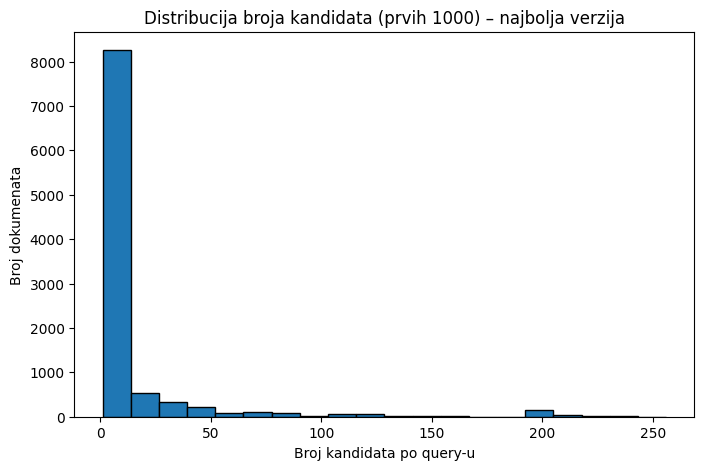

In [ ]:
counts_1000 = []
EVAL_Q2 = min(10000, len(df))

for qid in tqdm(range(EVAL_Q2), desc="Counts for first 1000"):
    cands = lsh_query_fast(sigs[qid], buckets, bands=BEST_BANDS, rows=BEST_ROWS)
    counts_1000.append(len(cands))

print("Broj sličnih dokumenata za prvih", EVAL_Q2, "query-a:")
print(counts_1000)

plt.figure(figsize=(8,5))
plt.hist(counts_1000, bins=20, edgecolor='black')
plt.xlabel("Broj kandidata po query-u")
plt.ylabel("Broj dokumenata")
plt.title("Distribucija broja kandidata (prvih 1000) – najbolja verzija")
plt.show()


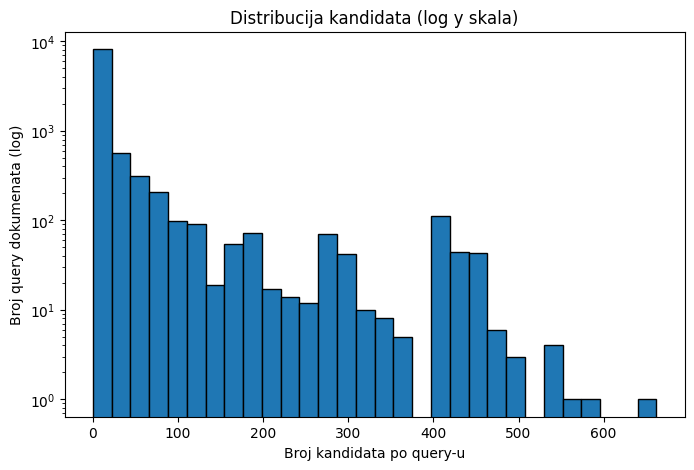

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(counts, bins=30, edgecolor="black")
plt.yscale("log")
plt.xlabel("Broj kandidata po query-u")
plt.ylabel("Broj query dokumenata (log)")
plt.title("Distribucija kandidata (log y skala)")
plt.show()


In [ ]:
counts_arr = np.array(counts)

n = len(counts_arr)
n_pos = np.sum(counts_arr > 0)
n0 = np.sum(counts_arr == 0)

print(f"Ukupno query-a: {n}")
print(f"Query-i sa 0 kandidata: {n0} ({n0/n:.2%})")
print(f"Query-i sa ≥1 kandidatom: {n_pos} ({n_pos/n:.2%})")

print("\nStatistika broja kandidata:")
print(f"Prosjek: {counts_arr.mean():.2f}")
print(f"Medijan: {np.median(counts_arr):.2f}")
print(f"95. percentil: {np.percentile(counts_arr, 95):.0f}")
print(f"Maksimum: {counts_arr.max()}")


Ukupno query-a: 500
Query-i sa 0 kandidata: 242 (48.40%)
Query-i sa ≥1 kandidatom: 258 (51.60%)

Statistika broja kandidata:
Prosjek: 5.34
Medijan: 1.00
95. percentil: 27
Maksimum: 195


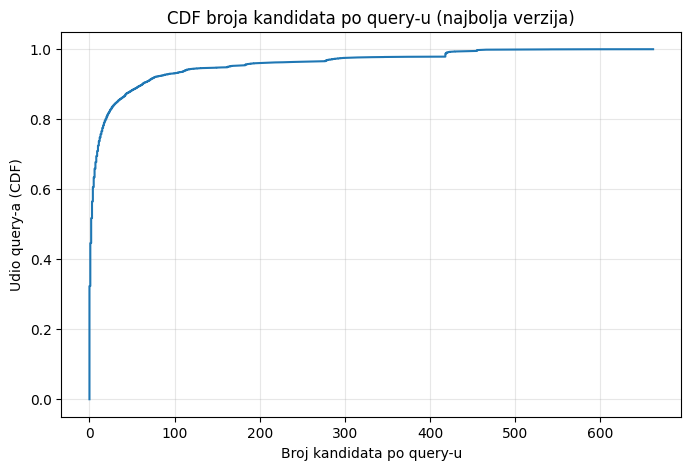

In [ ]:
counts_arr = np.array(counts)
x = np.sort(counts_arr)
y = np.arange(1, len(x) + 1) / len(x)

plt.figure(figsize=(8,5))
plt.plot(x, y)
plt.xlabel("Broj kandidata po query-u")
plt.ylabel("Udio query-a (CDF)")
plt.title("CDF broja kandidata po query-u (najbolja verzija)")
plt.grid(True, alpha=0.3)
plt.show()


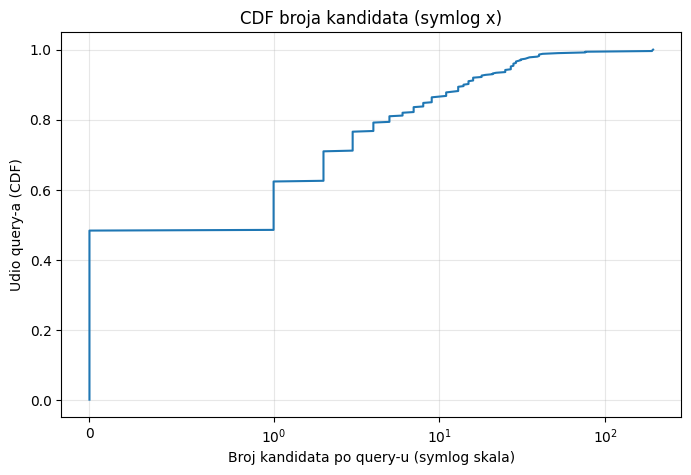

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(x, y)
plt.xscale("symlog", linthresh=1)  # log za veće vrijednosti, a normalno oko 0
plt.xlabel("Broj kandidata po query-u (symlog skala)")
plt.ylabel("Udio query-a (CDF)")
plt.title("CDF broja kandidata (symlog x)")
plt.grid(True, alpha=0.3)
plt.show()


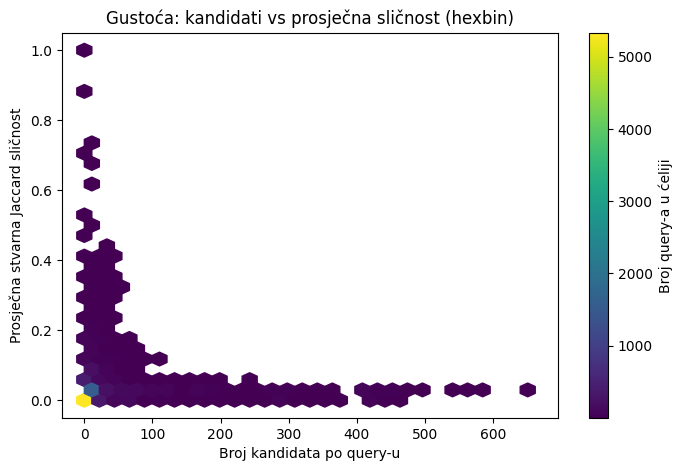

In [ ]:
x = np.array(counts)
y = np.array(avg_sims)

plt.figure(figsize=(8,5))
plt.hexbin(x, y, gridsize=30, mincnt=1)  # gustoća
plt.xlabel("Broj kandidata po query-u")
plt.ylabel("Prosječna stvarna Jaccard sličnost")
plt.title("Gustoća: kandidati vs prosječna sličnost (hexbin)")
plt.colorbar(label="Broj query-a u ćeliji")
plt.show()


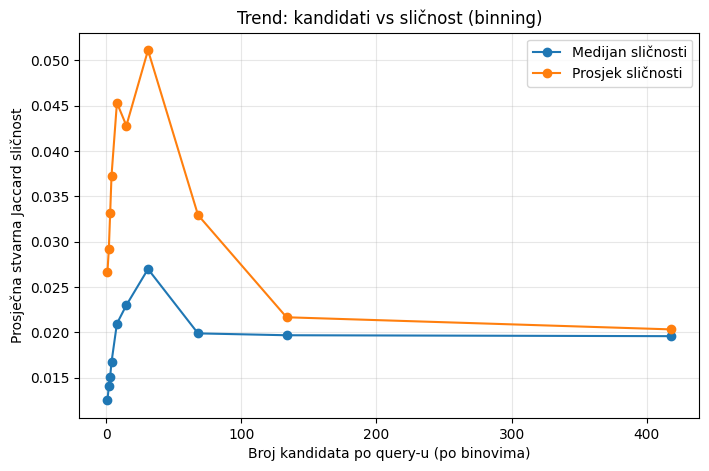

Veličine binova: [np.int64(1228), np.int64(712), np.int64(476), np.int64(690), np.int64(907), np.int64(828), np.int64(761), np.int64(480), np.int64(294), np.int64(392)]


In [ ]:
x = np.array(counts)
y = np.array(avg_sims)

# binovi po x (podesi po želji)
bins = [0,1,2,3,5,10,20,50,100,200]
bin_ids = np.digitize(x, bins, right=True)

bin_centers = []
medians = []
means = []
sizes = []

for b in range(1, len(bins)+1):
    mask = bin_ids == b
    if np.sum(mask) < 3:   # preskoči premale binove
        continue
    bin_centers.append(np.median(x[mask]))
    medians.append(np.median(y[mask]))
    means.append(np.mean(y[mask]))
    sizes.append(np.sum(mask))

plt.figure(figsize=(8,5))
plt.plot(bin_centers, medians, marker="o", label="Medijan sličnosti")
plt.plot(bin_centers, means, marker="o", label="Prosjek sličnosti")
plt.xlabel("Broj kandidata po query-u (po binovima)")
plt.ylabel("Prosječna stvarna Jaccard sličnost")
plt.title("Trend: kandidati vs sličnost (binning)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Veličine binova:", sizes)


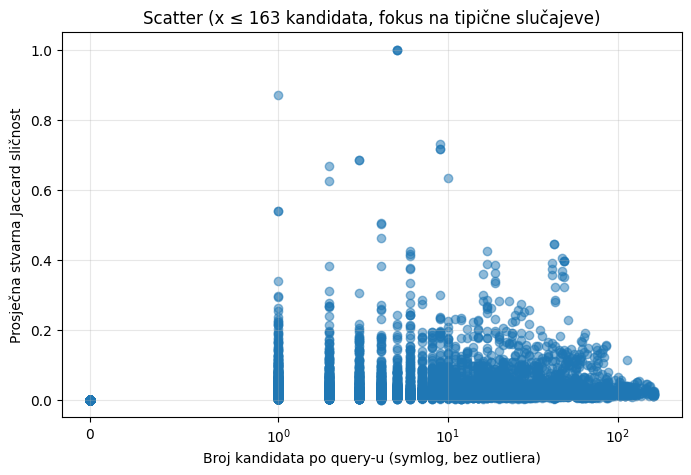

In [ ]:
x = np.array(counts)
y = np.array(avg_sims)

# odreži ekstremne outliere po x (npr. iznad 95. percentila)
cap = np.percentile(x, 95)
mask = x <= cap

plt.figure(figsize=(8,5))
plt.scatter(x[mask], y[mask], alpha=0.5)
plt.xscale("symlog", linthresh=1)
plt.xlabel("Broj kandidata po query-u (symlog, bez outliera)")
plt.ylabel("Prosječna stvarna Jaccard sličnost")
plt.title(f"Scatter (x ≤ {cap:.0f} kandidata, fokus na tipične slučajeve)")
plt.grid(True, alpha=0.3)
plt.show()


#Bibliotečke funkcije vs LSH



threshold ≈ (1 / bands)^(1/rows)


In [ ]:
def build_library_lsh_from_shingles(shingle_sets, num_perm=128, threshold=0.2):
    # MinHash potpisi
    minhashes = []
    for sh in tqdm(shingle_sets, desc=f"Library MinHash num_perm={num_perm}"):
        m = MinHash(num_perm=num_perm)
        for s in sh:
            m.update(s.encode("utf8"))
        minhashes.append(m)

    # LSH index
    lsh = MinHashLSH(threshold=threshold, num_perm=num_perm)
    for i, mh in enumerate(minhashes):
        lsh.insert(str(i), mh)
    return minhashes, lsh

def compare_manual_vs_library(
    signatures, buckets, bands, rows,
    shingle_sets,               # lista setova shingles (za brute force / Jaccard)
    num_perm_lib=128,
    threshold_lib=0.2,
    N_QUERIES=50, TOPK=10, seed=42
):
    rng = np.random.RandomState(seed)
    Q = min(N_QUERIES, len(signatures))
    query_ids = rng.choice(len(signatures), size=Q, replace=False)

    # --- build library ---
    minhashes_lib, lsh_lib = build_library_lsh_from_shingles(
        shingle_sets, num_perm=num_perm_lib, threshold=threshold_lib
    )

    def topk_bruteforce(qid, topk):
        qsh = shingle_sets[qid]
        sims = []
        for j in range(len(shingle_sets)):
            if j == qid:
                continue
            sims.append((j, jaccard_similarity(qsh, shingle_sets[j])))
        sims.sort(key=lambda x: x[1], reverse=True)
        return [j for j, s in sims[:topk]]

    # --- MANUAL stats ---
    t0 = time.time()
    hit_m, cand_m = [], []
    for qid in tqdm(query_ids, desc="Manual vs GT"):
        cands = lsh_query_fast(signatures[qid], buckets, bands=bands, rows=rows)
        cands.discard(qid)
        cand_m.append(len(cands))

        gt = set(topk_bruteforce(qid, TOPK))
        hit_m.append(len(gt & set(cands)) / TOPK)
    t_manual = time.time() - t0

    # --- LIB stats ---
    t0 = time.time()
    hit_l, cand_l = [], []
    for qid in tqdm(query_ids, desc="Library vs GT"):
        res = lsh_lib.query(minhashes_lib[qid])
        cands = {int(x) for x in res}
        cands.discard(qid)
        cand_l.append(len(cands))

        gt = set(topk_bruteforce(qid, TOPK))
        hit_l.append(len(gt & cands) / TOPK)
    t_lib = time.time() - t0

    return {
        "N_queries": Q,
        "TOPK": TOPK,
        "manual": {
            "bands": bands, "rows": rows,
            "time_sec": t_manual,
            "avg_candidates": float(np.mean(cand_m)),
            "median_candidates": float(np.median(cand_m)),
            "recall@TOPK": float(np.mean(hit_m)),
        },
        "library": {
            "num_perm": num_perm_lib, "threshold": threshold_lib,
            "time_sec": t_lib,
            "avg_candidates": float(np.mean(cand_l)),
            "median_candidates": float(np.median(cand_l)),
            "recall@TOPK": float(np.mean(hit_l)),
        }
    }


In [ ]:
# ručni parametri (tvoji najbolji)
NUM_PERM = 128
K = 2
SEED = 42
BANDS = 64
ROWS = 2

# build manual
shingles_for_doc.cache_clear()
sigs, _ = build_signatures(df, num_perm=NUM_PERM, k=K, seed=SEED)
buckets, _ = build_buckets(sigs, bands=BANDS, rows=ROWS)

# shingle_sets za brute force (da ne računa 100x)
shingle_sets = [shingles_for_doc(i, K) for i in range(len(df))]

# threshold za library (približno kao bands/rows)
threshold_lib = (1.0 / BANDS) ** (1.0 / ROWS)

report_ml = compare_manual_vs_library(
    signatures=sigs,
    buckets=buckets,
    bands=BANDS,
    rows=ROWS,
    shingle_sets=shingle_sets,
    num_perm_lib=NUM_PERM,
    threshold_lib=threshold_lib,
    N_QUERIES=50,
    TOPK=10,
    seed=42
)

report_ml


Library vs GT: 100%|██████████| 50/50 [00:57<00:00,  1.14s/it]


{'N_queries': 50,
 'TOPK': 10,
 'manual': {'bands': 64,
  'rows': 2,
  'time_sec': 55.91358947753906,
  'avg_candidates': 19.36,
  'median_candidates': 0.5,
  'recall@TOPK': 0.14200000000000002},
 'library': {'num_perm': 128,
  'threshold': 0.125,
  'time_sec': 57.01975607872009,
  'avg_candidates': 8.2,
  'median_candidates': 1.0,
  'recall@TOPK': 0.122}}

In [ ]:
NUM_PERM = 128
K = 2
SEED = 42
BANDS = 64
ROWS  = 2

# evaluacija
N_QUERIES = 50
TOPK = 10

# za "fer" threshold biblioteke (približno bands/rows pragu)
THRESHOLD_LIB = (1.0 / BANDS) ** (1.0 / ROWS)

# ====== PRECOMPUTE shingles (da brute force i evaluacija budu brži) ======
shingles_for_doc.cache_clear()
SHINGLE_SETS = [shingles_for_doc(i, K) for i in tqdm(range(len(df)), desc="Precompute shingles")]

# ====== MANUAL: signatures + buckets ======
sigs, t_sig = build_signatures(df, num_perm=NUM_PERM, k=K, seed=SEED)
buckets, t_b = build_buckets(sigs, bands=BANDS, rows=ROWS)

print("MANUAL build_sig_sec:", round(t_sig, 3))
print("MANUAL build_buckets_sec:", round(t_b, 3))

# ====== LIB: MinHash + LSH index ======
t0 = time.time()
minhashes_lib = []
for shset in tqdm(SHINGLE_SETS, desc=f"LIB MinHash num_perm={NUM_PERM}"):
    m = MinHash(num_perm=NUM_PERM)
    for s in shset:
        m.update(s.encode("utf8"))
    minhashes_lib.append(m)
t_mh = time.time() - t0

t0 = time.time()
lsh_lib = MinHashLSH(threshold=THRESHOLD_LIB, num_perm=NUM_PERM)
for i, m in enumerate(minhashes_lib):
    lsh_lib.insert(str(i), m)
t_lsh = time.time() - t0

print("LIB build_minhash_sec:", round(t_mh, 3))
print("LIB build_lsh_sec:", round(t_lsh, 3))
print("LIB threshold:", THRESHOLD_LIB)


Signatures num_perm=128, k=2: 100%|██████████| 10000/10000 [01:19<00:00, 126.21it/s]


MANUAL build_sig_sec: 79.256
MANUAL build_buckets_sec: 6.398


LIB MinHash num_perm=128: 100%|██████████| 10000/10000 [02:04<00:00, 80.09it/s]


LIB build_minhash_sec: 124.859
LIB build_lsh_sec: 4.048
LIB threshold: 0.125


In [ ]:
def topk_bruteforce_jaccard(qid: int, topk: int = 10):
    qset = SHINGLE_SETS[qid]
    heap = []  # min-heap od (sim, id)

    for j in range(len(SHINGLE_SETS)):
        if j == qid:
            continue
        sim = jaccard_similarity(qset, SHINGLE_SETS[j])

        if len(heap) < topk:
            heapq.heappush(heap, (sim, j))
        else:
            if sim > heap[0][0]:
                heapq.heapreplace(heap, (sim, j))

    heap.sort(reverse=True)  # najveći sim prvi
    return [jid for sim, jid in heap]


In [ ]:
rng = np.random.RandomState(SEED)
Q = min(N_QUERIES, len(df))
query_ids = rng.choice(len(df), size=Q, replace=False)

manual_cands = []
lib_cands = []
manual_recall = []
lib_recall = []
manual_time_ms = []
lib_time_ms = []

for qid in tqdm(query_ids, desc="Evaluating MANUAL vs LIB"):
    gt = set(topk_bruteforce_jaccard(qid, TOPK))

    # ---- MANUAL query ----
    t0 = time.time()
    cands_m = lsh_query_fast(sigs[qid], buckets, bands=BANDS, rows=ROWS)
    cands_m.discard(qid)
    tm = (time.time() - t0) * 1000.0

    manual_time_ms.append(tm)
    manual_cands.append(len(cands_m))
    manual_recall.append(len(gt & set(cands_m)) / TOPK)

    # ---- LIB query ----
    t0 = time.time()
    res = lsh_lib.query(minhashes_lib[qid])
    cands_l = {int(x) for x in res}
    cands_l.discard(qid)
    tl = (time.time() - t0) * 1000.0

    lib_time_ms.append(tl)
    lib_cands.append(len(cands_l))
    lib_recall.append(len(gt & cands_l) / TOPK)

print("Done.")

# sažetak
summary = {
    "manual_avg_candidates": float(np.mean(manual_cands)),
    "manual_median_candidates": float(np.median(manual_cands)),
    "manual_recall_at_topk": float(np.mean(manual_recall)),
    "manual_avg_query_ms": float(np.mean(manual_time_ms)),

    "lib_avg_candidates": float(np.mean(lib_cands)),
    "lib_median_candidates": float(np.median(lib_cands)),
    "lib_recall_at_topk": float(np.mean(lib_recall)),
    "lib_avg_query_ms": float(np.mean(lib_time_ms)),
}
summary


Evaluating MANUAL vs LIB: 100%|██████████| 50/50 [00:53<00:00,  1.08s/it]

Done.


{'manual_avg_candidates': 19.36,
 'manual_median_candidates': 0.5,
 'manual_recall_at_topk': 0.14400000000000002,
 'manual_avg_query_ms': 0.3039693832397461,
 'lib_avg_candidates': 8.2,
 'lib_median_candidates': 1.0,
 'lib_recall_at_topk': 0.122,
 'lib_avg_query_ms': 0.29097557067871094}

Grafovi usporedbe

/tmp/ipython-input-3318040792.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manual_cands, lib_cands], labels=["Manual", "Library"], showfliers=False)


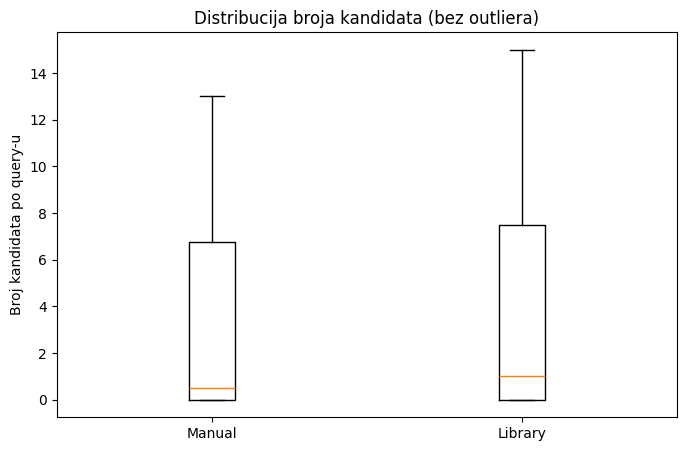

/tmp/ipython-input-3318040792.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([manual_time_ms, lib_time_ms], labels=["Manual", "Library"], showfliers=False)


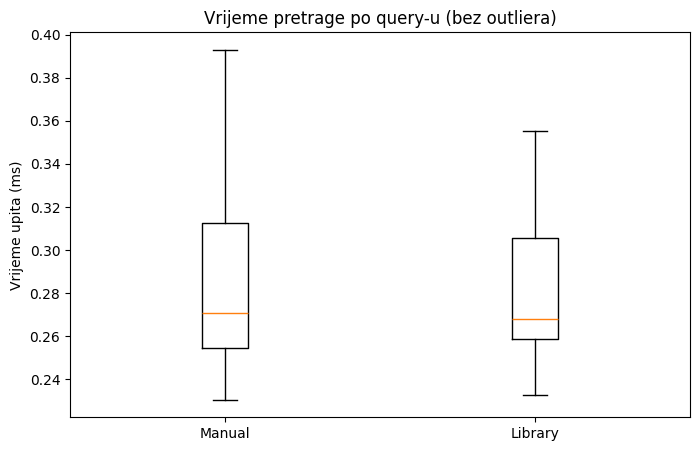

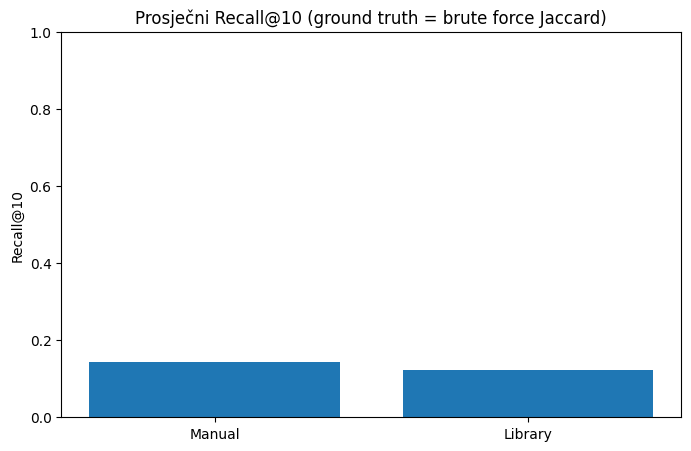

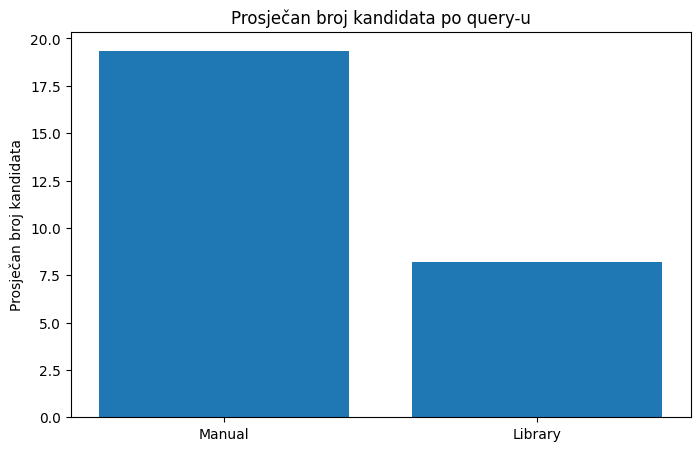

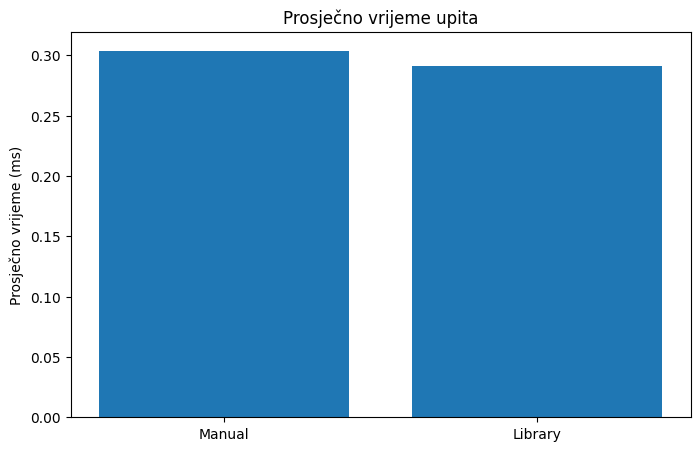

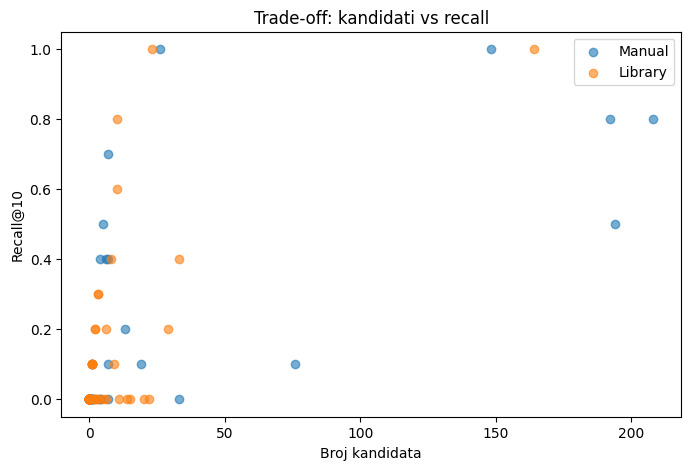

In [ ]:
# 1) Boxplot kandidata (distribucija)
plt.figure(figsize=(8, 5))
plt.boxplot([manual_cands, lib_cands], labels=["Manual", "Library"], showfliers=False)
plt.ylabel("Broj kandidata po query-u")
plt.title("Distribucija broja kandidata (bez outliera)")
plt.show()

# 2) Boxplot vremena po query-u
plt.figure(figsize=(8, 5))
plt.boxplot([manual_time_ms, lib_time_ms], labels=["Manual", "Library"], showfliers=False)
plt.ylabel("Vrijeme upita (ms)")
plt.title("Vrijeme pretrage po query-u (bez outliera)")
plt.show()

# 3) Bar: prosjek recall@TOPK + prosjek kandidata + prosjek ms
labels = ["Manual", "Library"]

plt.figure(figsize=(8, 5))
plt.bar(labels, [np.mean(manual_recall), np.mean(lib_recall)])
plt.ylim(0, 1)
plt.ylabel(f"Recall@{TOPK}")
plt.title(f"Prosječni Recall@{TOPK} (ground truth = brute force Jaccard)")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(labels, [np.mean(manual_cands), np.mean(lib_cands)])
plt.ylabel("Prosječan broj kandidata")
plt.title("Prosječan broj kandidata po query-u")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(labels, [np.mean(manual_time_ms), np.mean(lib_time_ms)])
plt.ylabel("Prosječno vrijeme (ms)")
plt.title("Prosječno vrijeme upita")
plt.show()

# 4) Scatter: kandidati vs recall (da vidiš trade-off)
plt.figure(figsize=(8, 5))
plt.scatter(manual_cands, manual_recall, alpha=0.6, label="Manual")
plt.scatter(lib_cands, lib_recall, alpha=0.6, label="Library")
plt.xlabel("Broj kandidata")
plt.ylabel(f"Recall@{TOPK}")
plt.title("Trade-off: kandidati vs recall")
plt.legend()
plt.show()


#Bibliotečka

In [ ]:
BEST_K = 2
NUM_PERM = 128
THRESHOLD = 0.125

# Precompute shinglovi
shingle_sets = [shingles_for_doc(i, BEST_K) for i in tqdm(range(len(df)), desc="Precompute shingles")]

# Build (tvoja funkcija)
minhashes_lib, lsh_lib = build_library_lsh_from_shingles(
    shingle_sets=shingle_sets,
    num_perm=NUM_PERM,
    threshold=THRESHOLD
)


Library MinHash num_perm=128: 100%|██████████| 10000/10000 [02:04<00:00, 80.33it/s]


Evaluating BEST LSH (library): 100%|██████████| 500/500 [00:03<00:00, 131.08it/s]


Gotovo – evaluirano 500 querya (library).
Top 5 query dokumenata s najviše kandidata (library):
1. Query ID: 172, Broj kandidata: 163, Prosj. Jaccard: 0.023
2. Query ID: 470, Broj kandidata: 81, Prosj. Jaccard: 0.008
3. Query ID: 446, Broj kandidata: 74, Prosj. Jaccard: 0.022
4. Query ID: 175, Broj kandidata: 51, Prosj. Jaccard: 0.007
5. Query ID: 80, Broj kandidata: 51, Prosj. Jaccard: 0.005


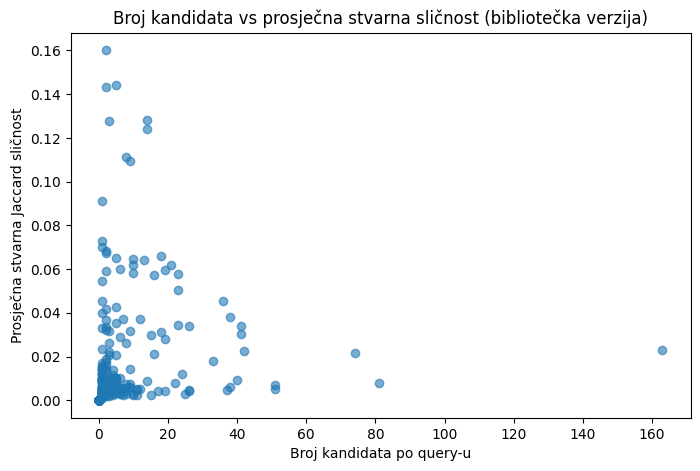

In [ ]:
EVAL_Q = min(500, len(df))
counts_lib = []
avg_sims_lib = []

for qid in tqdm(range(EVAL_Q), desc="Evaluating BEST LSH (library)"):
    # kandidati iz bibliotečkog LSH
    result_ids = lsh_lib.query(minhashes_lib[qid])
    cands = {int(x) for x in result_ids if int(x) < len(df)}
    cands.discard(qid)

    counts_lib.append(len(cands))

    # prosječna stvarna Jaccard sličnost (nad shinglovima)
    sh_q = shingle_sets[qid]

    sims = []
    for cid in list(cands):  # možeš ograničiti npr. list(cands)[:200]
        sh_c = shingle_sets[cid]
        sims.append(jaccard_similarity(sh_q, sh_c))

    avg_sims_lib.append(float(np.mean(sims)) if sims else 0.0)

print("Gotovo – evaluirano", EVAL_Q, "querya (library).")

top5_indices = np.argsort(counts_lib)[-5:][::-1]
print("Top 5 query dokumenata s najviše kandidata (library):")
for rank, qid in enumerate(top5_indices, 1):
    print(f"{rank}. Query ID: {qid}, Broj kandidata: {counts_lib[qid]}, Prosj. Jaccard: {avg_sims_lib[qid]:.3f}")

# Scatter: broj kandidata vs prosječna sličnost
plt.figure(figsize=(8,5))
plt.scatter(counts_lib, avg_sims_lib, alpha=0.6)
plt.xlabel("Broj kandidata po query-u")
plt.ylabel("Prosječna stvarna Jaccard sličnost")
plt.title("Broj kandidata vs prosječna stvarna sličnost (bibliotečka verzija)")
plt.show()


In [ ]:
for rank, qid in enumerate(top5_indices, 1):
    print(f"\n=== Query {rank}: ID {qid} ===")
    print("Title:", df.loc[qid, "title"])

    cands = lsh_query_fast(sigs[qid], buckets, bands=BEST_BANDS, rows=BEST_ROWS)
    cands.discard(qid)

    sh_q = shingles_for_doc(qid, BEST_K)
    sims_list = []

    for cid in list(cands)[:50]:  # uzmi do 50 kandidata, pa sortiraj
        sh_c = shingles_for_doc(cid, BEST_K)
        sim = jaccard_similarity(sh_q, sh_c)
        sims_list.append((cid, sim))

    sims_list.sort(key=lambda x: x[1], reverse=True)

    print("Top kandidati s Jaccard sličnostima:")
    for cid, sim in sims_list[:10]:
        print(f"- ID {cid}, sličnost: {sim:.3f}, Title: {df.loc[cid, 'title']}")



=== Query 1: ID 172 ===
Title: Arne Kaijser
Top kandidati s Jaccard sličnostima:
- ID 8768, sličnost: 0.037, Title: Michael L. Chyet
- ID 8781, sličnost: 0.034, Title: Deng Weizhi
- ID 4645, sličnost: 0.033, Title: Ernie Vincze
- ID 5575, sličnost: 0.029, Title: Lyle Neff
- ID 6987, sličnost: 0.025, Title: Ann Jungman
- ID 7534, sličnost: 0.024, Title: Joël Henry (journalist)
- ID 7191, sličnost: 0.020, Title: Zvi Magen
- ID 6957, sličnost: 0.015, Title: Paul Coletti

=== Query 2: ID 470 ===
Title: Agapanthus africanus
Top kandidati s Jaccard sličnostima:

=== Query 3: ID 446 ===
Title: Lory (disambiguation)
Top kandidati s Jaccard sličnostima:

=== Query 4: ID 175 ===
Title: Andrey Markov
Top kandidati s Jaccard sličnostima:
- ID 9128, sličnost: 0.013, Title: Verzuolo
- ID 5208, sličnost: 0.011, Title: John Kinsella (swimmer)
- ID 9424, sličnost: 0.011, Title: Shamsuddin Kayumars
- ID 3037, sličnost: 0.011, Title: Ronald Jansen
- ID 5659, sličnost: 0.011, Title: Ruth Langsford
- ID 7